## Products Delivery Risk Fraud Prediction in Supply Chain Analytics

**Prepared By: Olumide Johnson Ikumapayi**

### Project Description

Developed a machine learning classification framework to predict late delivery risk in supply chain operations using structured transactional data. The project integrated order-level, shipping, and customer-related variables to model delivery performance and classify records according to the probability of delay. The resulting framework supported risk-based identification of shipments with elevated likelihood of late delivery, enabling earlier operational intervention and more informed logistics planning.

**Motivation**

This project was motivated by the need to improve the accuracy of late delivery risk detection in supply chain transactions. In logistics environments, delayed deliveries can disrupt inventory flow, increase operational costs, and reduce customer satisfaction. A predictive approach was therefore necessary to identify high-risk transactions before delivery failure occurs and to support more effective decision-making.

**Project Objective**

The objective of this project was to design and implement a predictive classification model that identifies the key determinants of late delivery in supply chain operations. Using machine learning techniques, the model evaluates order, customer, and shipping-related features to estimate delivery risk and classify transactions into delay-risk categories. The project aimed to produce a data-driven decision support tool that could enhance logistics forecasting, improve operational responsiveness, and strengthen supply chain efficiency.

**About the Dataset**

The project used the DataCo Smart Supply Chain dataset, referenced as “DataCo smart supply chain for big data analysis.” The dataset contains structured supply chain records with variables related to orders, shipments, customers, products, and delivery outcomes. Its breadth and operational relevance make it suitable for supervised learning tasks involving predictive analysis of logistics risk.The dataset can be downloaded from Kaggle public repository:https://github.com/kowshik14/FraudDetection-SupplyChain

**Problem Formulation**

This work was formulated as a supervised binary classification problem. The target variable, **Late_delivery_risk**, represents delivery status as:

* 1 = late delivery / high risk
* 0 = on-time delivery / low risk

The model was developed to learn the relationship between input variables and delivery outcomes, with the goal of accurately distinguishing high-risk transactions from normal deliveries.

**Technical Significance**

From a technical standpoint, the project demonstrates the application of machine learning to predictive risk modeling in supply chain systems. By transforming historical logistics data into a classification-based forecasting tool, the work contributes to the use of artificial intelligence for operational optimization, delay mitigation, and service reliability improvement in data-intensive business environments.


The flow of the **The Supply Chain Fraud Detection** dataset is as follows:

1. [Importing libraries](#Importing-libraries)
2. [Data Acquisition & Initial Inspection](#Data-Acquisition-&-Initial-Inspection)
3. [Data Cleaning & Missing Values](#Data-Cleaning-&-Missing-Values)
4. [Description of the Dataset](#Description-of-the-Dataset)
5. [Exploratory Data Analysis (EDA)](#Exploratory-Data-Analysis-(EDA))
6. [Correlation Analysis](#Correlation-Analysis)
7. [Feature Engineering & Preprocessing](#Feature-Engineering-&-Preprocessing)
8. [Handling imbalanced target variable Using SMOTE](#Handling-imbalanced-target-variable-Using-SMOTE)
9. [Machine Learning Models](#Machine-Learning-Models)
10.[Summary and Conclusion](#Summary-and-Conclusion)

### Importing libraries

In [1]:
# Standard Library
import warnings
warnings.filterwarnings('ignore')

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import boxcox, zscore
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Preprocessing & Feature Engineering
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn import datasets, metrics, model_selection

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE, SMOTENC

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Pipeline
from sklearn.pipeline import Pipeline

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.metrics import RocCurveDisplay, plot_roc_curve

# Model Saving
import joblib

### Data Acquisition & Initial Inspection

#### Loading the dataset

In [2]:
df_supply_chainRisk = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')
df_supply_chainRisk.head(4)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,03/02/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,01/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,01/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,01/16/2018 11:45,Standard Class


In [3]:
df_supply_chainRisk.tail(4)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,01/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,01/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,01/18/2016 20:18,Standard Class
180518,PAYMENT,4,4,168.949997,383.980011,Shipping on time,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,01/19/2016 18:54,Standard Class


**Inspecting shape, column, types, missing values and Other Basic Statistics**

In [4]:
# Checking the dataset dimension
df_supply_chainRisk.shape

(180519, 53)

The dataset contains 180,519 rows and 53 columns.Of which 1 is target variable and the remaining 52 are independent varbiables.

In [5]:
# Check column of the dataset
df_supply_chainRisk.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

This is a confirmation that we have a large transactional dataset with lots of variables to work with regarding our target **late-delivery risk**.

In [6]:
# Checking the list of columns for dataset
df_supply_chainRisk.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [7]:
# checking the types of columns
df_supply_chainRisk.dtypes

Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market          

The dataset has **180,519** rows and **53** columns containing three**(3)** different types of data(object, int64 and float64) broken into **24** object (text) columns,**14** integer columns and **15** float columns.This is a large, rich dataset which gives plenty of room to build a strong late-delivery prediction model.

In [8]:
# Checking the column info
df_supply_chainRisk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

Above are some of the attributes of the dataset,which includes **indexing type**,**column type**,**non null values and memory usage**.Also there are some missing values in the dataset which we must treat.

### Data Cleaning & Missing Values

**Handling null, missing and inconsistent data**

In [9]:
# checking null values
df_supply_chainRisk.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [10]:
# Missing values
df_supply_chainRisk.isna().sum().sort_values(ascending=False).head(20)

Product Description         180519
Order Zipcode               155679
Customer Lname                   8
Customer Zipcode                 3
Type                             0
Order Profit Per Order           0
Order Item Cardprod Id           0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Id                    0
Order Item Product Price         0
Order Item Profit Ratio          0
Order Item Quantity              0
Sales                            0
Order Item Total                 0
Order Region                     0
order date (DateOrders)          0
Order State                      0
Order Status                     0
Product Card Id                  0
dtype: int64

We have identified some of the null/missing values

In [11]:
# The total Number of missing values in the dataset
df_supply_chainRisk.isnull().sum().sum()

336209

In [12]:
# Target distribution
print(df_supply_chainRisk["Delivery Status"].value_counts())
print(df_supply_chainRisk["Late_delivery_risk"].value_counts())

Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: Delivery Status, dtype: int64
1    98977
0    81542
Name: Late_delivery_risk, dtype: int64


In [13]:
# Delay gap (real - scheduled)
df_supply_chainRisk["delay_gap"] = df_supply_chainRisk["Days for shipping (real)"] - df_supply_chainRisk["Days for shipment (scheduled)"]

In [14]:
# Tight schedule flag (scheduled ≤ 2 days)
df_supply_chainRisk["is_tight_schedule"] = (df_supply_chainRisk["Days for shipment (scheduled)"] <= 2).astype(int)

In [15]:
# Shipping mode risk (target encoding)
shipping_mode_risk = df_supply_chainRisk.groupby("Shipping Mode")["Late_delivery_risk"].mean()
df_supply_chainRisk["shipping_mode_risk"] = df_supply_chainRisk["Shipping Mode"].map(shipping_mode_risk)

In [16]:
# Category risk (target encoding)
category_risk = df_supply_chainRisk.groupby("Category Name")["Late_delivery_risk"].mean()
df_supply_chainRisk["category_risk"] = df_supply_chainRisk["Category Name"].map(category_risk)

In [17]:
# Market risk (target encoding)
market_risk = df_supply_chainRisk.groupby("Market")["Late_delivery_risk"].mean()
df_supply_chainRisk["market_risk"] = df_supply_chainRisk["Market"].map(market_risk)

In [18]:
# Date features from shipping timestamp
df_supply_chainRisk["shipping_date"] = pd.to_datetime(df_supply_chainRisk["shipping date (DateOrders)"], errors="coerce")
df_supply_chainRisk["ship_month"] = df_supply_chainRisk["shipping_date"].dt.month
df_supply_chainRisk["ship_weekday"] = df_supply_chainRisk["shipping_date"].dt.weekday  # Monday=0

### Droping useless / highly-noisy columns

**Treating the Missing Values**

In [19]:
cols_to_drop = [
    "Product Description",      # all missing
    "Product Status",           # all zero
    "Product Image",            # long URL text
    "Customer Email",           # PII / irrelevant
    "Customer Password",        # PII / irrelevant
    "Order Id",                 # identifiers
    "Customer Id",
    "Customer Lname",
    "Customer Zipcode", 
    "Order Customer Id",
    "Order Item Cardprod Id",
    "Order Item Id",
    "Order Zipcode",
    "Product Card Id",
    "Product Category Id",
    "shipping date (DateOrders)",   # raw timestamp, replaced by derived features
    "shipping_date"                 # datetime object, we keep numeric parts
]

# Drop if they exist
df_supply_chainRisk = df_supply_chainRisk.drop(columns=[c for c in cols_to_drop if c in df_supply_chainRisk.columns])

In [20]:
# Check again the null values
df_supply_chainRisk.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Fname                   0
Customer Segment                 0
Customer State                   0
Customer Street                  0
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
order date (DateOrders)          0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Product Price         0
Order Item Profit Ratio          0
Order Item Quantity              0
Sales               

The null values has now been treated

In [21]:
# Let's have a better overview of the dataset
df_supply_chainRisk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 44 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Segment              

There are no more missing values in the DataSet, all complete **180519**.

<AxesSubplot:>

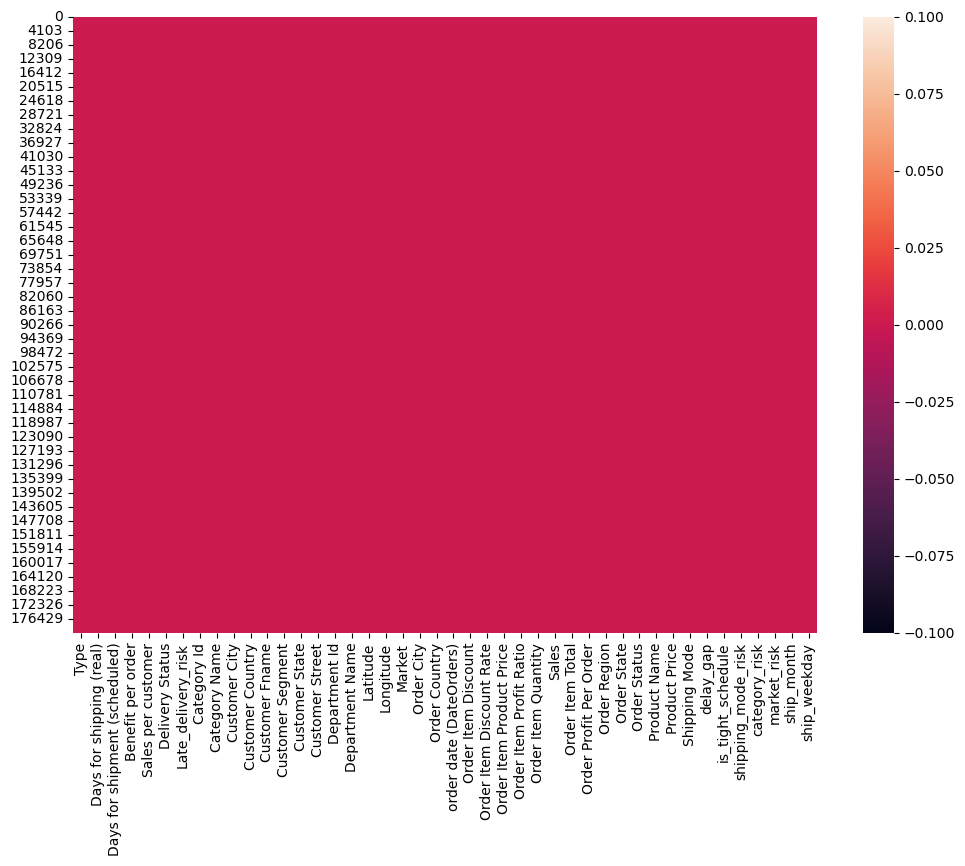

In [22]:
# Let's Visualize using heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_supply_chainRisk.isnull())

It has clearly shown that there are no more missing data in the dataset.

#### Defining the target and feature matrix

In [23]:
# Target
y = df_supply_chainRisk["Late_delivery_risk"]

# Features
X = df_supply_chainRisk.drop(columns=["Late_delivery_risk"])

#### Identifying the categorical and numeric columns

In [24]:
# Separating the numerical from categorical columns

# checking out the categorical columns
categorical_col = []
for i in df_supply_chainRisk.dtypes.index:
    if df_supply_chainRisk.dtypes[i] == "object":
        categorical_col.append(i)
print("categorical columns:", categorical_col)
print("\n")

# Checking for Numerical column
numerical_col = []
for i in df_supply_chainRisk.dtypes.index:
    if df_supply_chainRisk.dtypes[i]!= "object":
        numerical_col.append(i)
print("numerical columns:", numerical_col)

categorical columns: ['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Shipping Mode']


numerical columns: ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Department Id', 'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price', 'delay_gap', 'is_tight_schedule', 'shipping_mode_risk', 'category_risk', 'market_risk', 'ship_month', 'ship_weekday']


The dataset includes both **categorical and numerical variables**, showing that late delivery risk depends on multiple factors such as customer details, shipping mode, product category, geography, timing, sales, and profit patterns. It also contains engineered features like delay_gap, shipping_mode_risk, and market_risk, which suggest that feature engineering is applied to improve prediction.this dataset is well-structured for a binary classification task aimed at identifying whether a delivery is likely to be **late** or **on time**.

In [25]:
# Checking the unique values of objects-column
for col in df_supply_chainRisk.select_dtypes(include='object').columns:
    print(col)
    print(df_supply_chainRisk[col].unique())

Type
['DEBIT' 'TRANSFER' 'CASH' 'PAYMENT']
Delivery Status
['Advance shipping' 'Late delivery' 'Shipping on time' 'Shipping canceled']
Category Name
['Sporting Goods' 'Cleats' 'Shop By Sport' "Women's Apparel" 'Electronics'
 'Boxing & MMA' 'Cardio Equipment' 'Trade-In' "Kids' Golf Clubs"
 'Hunting & Shooting' 'Baseball & Softball' "Men's Footwear"
 'Camping & Hiking' 'Consumer Electronics' 'Cameras ' 'Computers'
 'Basketball' 'Soccer' "Girls' Apparel" 'Accessories' "Women's Clothing"
 'Crafts' "Men's Clothing" 'Tennis & Racquet' 'Fitness Accessories'
 'As Seen on  TV!' 'Golf Balls' 'Strength Training' "Children's Clothing"
 'Lacrosse' 'Baby ' 'Fishing' 'Books ' 'DVDs' 'CDs ' 'Garden' 'Hockey'
 'Pet Supplies' 'Health and Beauty' 'Music' 'Video Games' 'Golf Gloves'
 'Golf Bags & Carts' 'Golf Shoes' 'Golf Apparel' "Women's Golf Clubs"
 "Men's Golf Clubs" 'Toys' 'Water Sports' 'Indoor/Outdoor Games']
Customer City
['Caguas' 'San Jose' 'Los Angeles' 'Tonawanda' 'Miami' 'San Ramon'
 'Freepor

In [26]:
# Finding number of unique values in the column
df_supply_chainRisk.nunique().to_frame("No.of unique values")

,No.of unique values
Type,4
Days for shipping (real),7
Days for shipment (scheduled),4
Benefit per order,21998
Sales per customer,2927
Delivery Status,4
Late_delivery_risk,2
Category Id,51
Category Name,50
Customer City,563


All the features have more than one single value except for Product Status, Production Description, Customer Password and Customer Email.

In [27]:
df_supply_chainRisk.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Name,Product Price,Shipping Mode,delay_gap,is_tight_schedule,shipping_mode_risk,category_risk,market_risk,ship_month,ship_weekday
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Smart watch,327.75,Standard Class,-1,0,0.380717,0.554622,0.55046,3,4
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Smart watch,327.75,Standard Class,1,0,0.380717,0.554622,0.55046,1,3
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Smart watch,327.75,Standard Class,0,0,0.380717,0.554622,0.55046,1,2
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Smart watch,327.75,Standard Class,-1,0,0.380717,0.554622,0.55046,1,1
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Smart watch,327.75,Standard Class,-2,0,0.380717,0.554622,0.55046,1,0


In [28]:
# Checking the list of counts of target
df_supply_chainRisk["Late_delivery_risk"].unique()

array([0, 1], dtype=int64)

There are two categories present in the target column namely "0" and "1"

In [29]:
# Checking the unique values in target column
df_supply_chainRisk['Late_delivery_risk'].value_counts()

1    98977
0    81542
Name: Late_delivery_risk, dtype: int64

We would assume that "1" stands for late delivery (high risk) and "0" for on-time delivery (low risk).

### Description of the Dataset

In [30]:
# Statistical summary of numerical columns
df_supply_chainRisk.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Department Id,Latitude,Longitude,Order Item Discount,...,Order Item Total,Order Profit Per Order,Product Price,delay_gap,is_tight_schedule,shipping_mode_risk,category_risk,market_risk,ship_month,ship_weekday
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,5.443460,29.719955,-84.915675,20.664741,...,183.107609,21.974989,141.232550,0.565807,0.403099,0.548291,0.548291,0.548291,6.343033,2.995923
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,1.629246,9.813646,21.433241,21.800901,...,120.043670,104.433526,139.732492,1.490966,0.490522,0.227477,0.007671,0.003445,3.422137,2.003486
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,2.000000,-33.937553,-158.025986,0.000000,...,7.490000,-4274.979980,9.990000,-2.000000,0.000000,0.380717,0.477032,0.543552,1.000000,0.000000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,4.000000,18.265432,-98.446312,5.400000,...,104.379997,7.000000,50.000000,0.000000,0.000000,0.380717,0.545342,0.543552,3.000000,1.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,5.000000,33.144863,-76.847908,14.000000,...,163.990005,31.520000,59.990002,1.000000,0.000000,0.380717,0.547466,0.550460,6.000000,3.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,7.000000,39.279617,-66.370583,29.990000,...,247.399994,64.800003,199.990005,1.000000,1.000000,0.766328,0.549713,0.552078,9.000000,5.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,12.000000,48.781933,115.263077,500.000000,...,1939.989990,911.799988,1999.989990,4.000000,1.000000,0.953225,0.688525,0.552078,12.000000,6.000000


These are the statistical details of the numerical columns.The dataset summary looks a bit better.

From the above we can provide key Numeric insight-:

1.  The counts of all the columns are of same values,meaning there are no missing values in the dataset.


2.  **Days for shipping(real)**: The Actual shipping duration with Mean: ~3.50 days, Min: 0, Max: 6, Median: 3 and 75th percentile: 5 .This variable looks clean and well-behaved. Nothing extreme and will later be compared between late vs non-late deliveries.


3. **Days for shipment(scheduled)**: The Planned shipping duration has Mean: ~2.93 days, Median: 4, Max: 4 hence, the Scheduled days max out at exactly 4, while real shipping goes to 6 which suggests that delays had occured when actual days exceed scheduled days.This is one of your strongest predictor variables. 


4. **Benefit per order**: The Wide range is from -4274 to +7605, Large variability (std ~104). The Negative(-ve) values represent losses after discounts.We would later look out for unprofitable orders which has tendency to delay more.


5.  **Sales per customer**: With Mean value of 183, Max of 870 Looks normal. The Higher-value orders may be prioritized; whic we would check later.


6. **Product Price**: Ranges from $9.99 to 1999.99 dollars which is a Huge spread and could influence shipping mode and risk.

In summary, the actual shipping time has more variation than scheduled time  which is likely tied to delays.Also, several order-related numeric variables e.g.price, profit, sales e.t.c. show wide ranges, which could affect risk patterns.There are no major outlier or data quality issues.

In [31]:
# Lets also check the statistical distribution for numerical features
df_supply_chainRisk.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933
Longitude,180519.0,-84.915675,21.433241,-158.025986,-98.446312,-76.847908,-66.370583,115.263077
Order Item Discount,180519.0,20.664741,21.800901,0.000000,5.400000,14.000000,29.990000,500.000000


### Exploratory Data Analysis (EDA)

**Univariate Analysis**

In [32]:
# The number of supply chain delivery risk
print(df_supply_chainRisk['Late_delivery_risk'].value_counts())

1    98977
0    81542
Name: Late_delivery_risk, dtype: int64


In [33]:
# The % rate of late delivery risk
target_df=df_supply_chainRisk['Late_delivery_risk'].value_counts()*100/df_supply_chainRisk.shape[0]
target_df

1    54.829132
0    45.170868
Name: Late_delivery_risk, dtype: float64

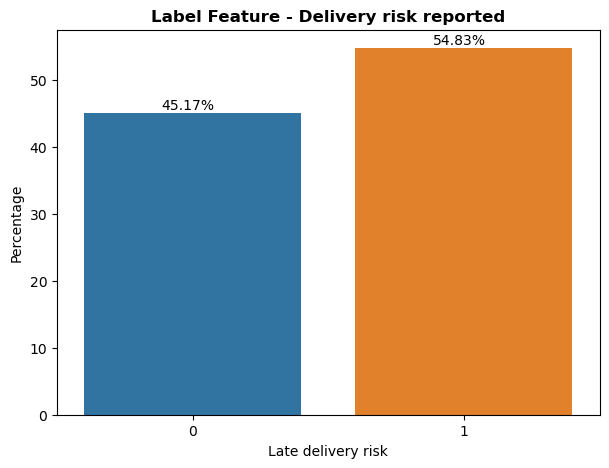

In [34]:
plt.figure(figsize=(7,5))
plt.title("Label Feature - Delivery risk reported",fontdict={'fontweight':'bold','fontsize':12})
ax=sns.barplot(x=target_df.index,y=target_df.values)
plt.xlabel('Late delivery risk')
plt.ylabel('Percentage')

for p in ax.patches:
    height=p.get_height()
    width=p.get_width()
    x,_=p.get_xy()
    ax.text(x+width/2.8,height+0.5,f'{height:.2f}%')

Here, the count of **"late delivery (high risk)"** is higher than that of **"on-time delivery (low risk)"** i.e.there are increased cases of late delivery.This leads to **CLASS IMBALANCE** issue in the data.we will therefore correct it by using **OVERSAMPLING METHOD** later as we progress.

In [35]:
# Identify the categorical variables
categorical_variables=[feature for feature in df_supply_chainRisk.columns if ((df_supply_chainRisk[feature].dtypes=='O') & (feature not in ['risk']))]
categorical_variables

['Type',
 'Delivery Status',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Fname',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Department Name',
 'Market',
 'Order City',
 'Order Country',
 'order date (DateOrders)',
 'Order Region',
 'Order State',
 'Order Status',
 'Product Name',
 'Shipping Mode']

Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: Delivery Status, dtype: int64


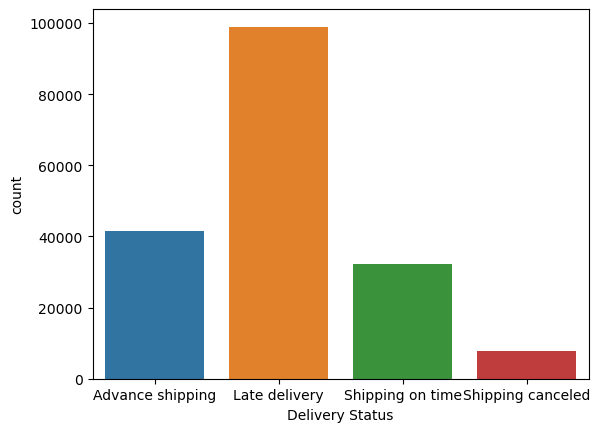

In [36]:
# Visualizing the count of Delivery Status
print(df_supply_chainRisk['Delivery Status'].value_counts())
ax = sns.countplot(x='Delivery Status', data=df_supply_chainRisk)
plt.show()

This chart shows that **late delivery** is the most frequent delivery status by a wide margin, indicating that delayed shipments make up the largest share of transactions. **Advance shipping** and **shipping on time** appear at much lower but still notable levels, while **shipping canceled** has the smallest count. Overall, this suggests that delivery delays are a major operational pattern in the dataset.


EE. UU.        111146
Puerto Rico     69373
Name: Customer Country, dtype: int64


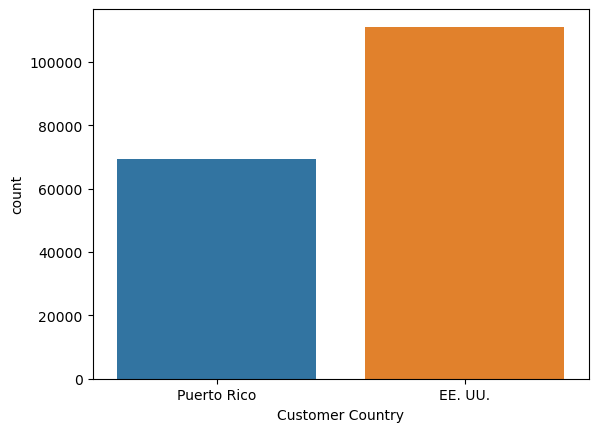

In [37]:
# Visualizing the count of Customer Country
print(df_supply_chainRisk['Customer Country'].value_counts())
ax = sns.countplot(x='Customer Country', data=df_supply_chainRisk)
plt.show()

The chart indicates that most customers are from the **United States (EE. UU.)**, while **Puerto Rico** also represents a substantial share. This suggests that the customer base is concentrated in these two locations, which may influence delivery patterns, shipping performance, and regional risk trends in the analysis.


Consumer       93504
Corporate      54789
Home Office    32226
Name: Customer Segment, dtype: int64


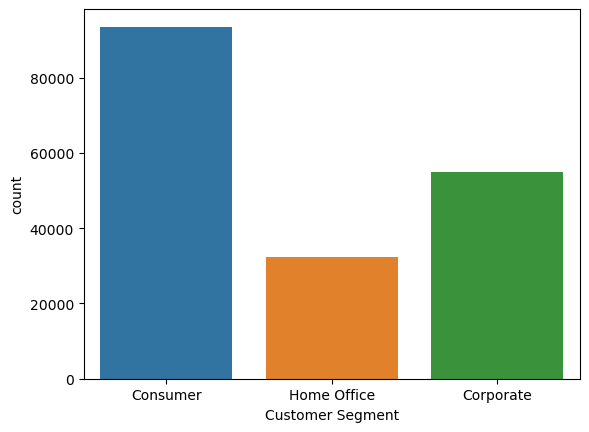

In [38]:
# Visualizing the count of Customer Segment
print(df_supply_chainRisk['Customer Segment'].value_counts())
ax = sns.countplot(x='Customer Segment', data=df_supply_chainRisk)
plt.show()

This distribution shows that the **Consumer** segment has the highest number of transactions, followed by **Corporate**, while **Home Office** has the lowest count. This indicates that consumer customers make up the largest share of the dataset, suggesting that delivery risk patterns may be driven more strongly by individual retail orders than by business or home office transactions.


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]),
 [Text(0, 0, 'PR'),
  Text(1, 0, 'CA'),
  Text(2, 0, 'NY'),
  Text(3, 0, 'TX'),
  Text(4, 0, 'IL'),
  Text(5, 0, 'FL'),
  Text(6, 0, 'OH'),
  Text(7, 0, 'PA'),
  Text(8, 0, 'MI'),
  Text(9, 0, 'NJ'),
  Text(10, 0, 'AZ'),
  Text(11, 0, 'GA'),
  Text(12, 0, 'MD'),
  Text(13, 0, 'NC'),
  Text(14, 0, 'CO'),
  Text(15, 0, 'VA'),
  Text(16, 0, 'OR'),
  Text(17, 0, 'MA'),
  Text(18, 0, 'TN'),
  Text(19, 0, 'NV'),
  Text(20, 0, 'MO'),
  Text(21, 0, 'HI'),
  Text(22, 0, 'CT'),
  Text(23, 0, 'UT'),
  Text(24, 0, 'NM'),
  Text(25, 0, 'LA'),
  Text(26, 0, 'WA'),
  Text(27, 0, 'WI'),
  Text(28, 0, 'MN'),
  Text(29, 0, 'SC'),
  Text(30, 0, 'IN'),
  Text(31, 0, 'DC'),
  Text(32, 0, 'KY'),
  Text(33, 0, 'KS'),
  Text(34, 0, 'DE'),
  Text(35, 0, 'RI'),
  Text(36, 0, 'WV'),
  Text(37, 0, 'OK'),
  

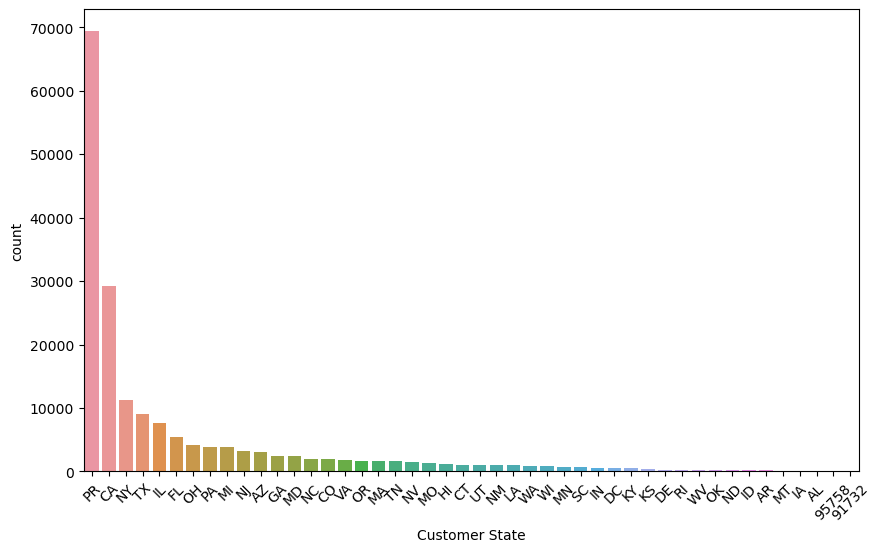

In [39]:
# Visualizing the count of Customer State
plt.figure(figsize=(10,6))
sns.countplot(df_supply_chainRisk['Customer State'],order=df_supply_chainRisk['Customer State'].value_counts().index)
plt.xticks(rotation=45)

The chart shows that customer transactions are heavily concentrated in a few states, with **Puerto Rico (PR)** having the highest count by a large margin, followed by **California (CA)** and several other states at much lower levels. Most remaining states contribute relatively small transaction volumes, indicating an uneven geographic distribution. This suggests that regional concentration may play an important role in customer activity and could influence delivery risk patterns across locations.


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 [Text(0, 0, 'Fan Shop'),
  Text(1, 0, 'Apparel'),
  Text(2, 0, 'Golf'),
  Text(3, 0, 'Footwear'),
  Text(4, 0, 'Outdoors'),
  Text(5, 0, 'Fitness'),
  Text(6, 0, 'Discs Shop'),
  Text(7, 0, 'Technology'),
  Text(8, 0, 'Pet Shop'),
  Text(9, 0, 'Book Shop'),
  Text(10, 0, 'Health and Beauty ')])

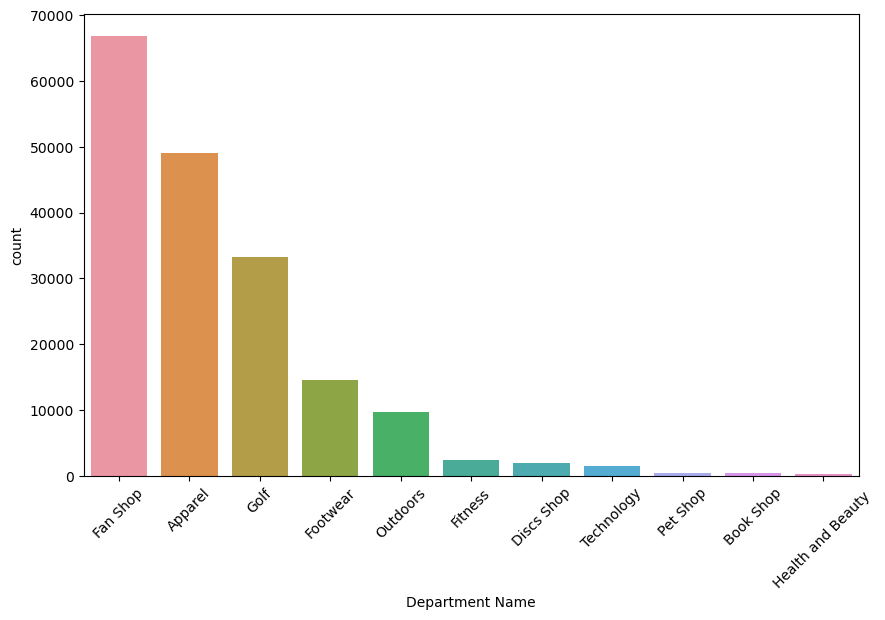

In [40]:
# Visualizing the count of Department Name
plt.figure(figsize=(10,6))
sns.countplot(df_supply_chainRisk['Department Name'],order=df_supply_chainRisk['Department Name'].value_counts().index)
plt.xticks(rotation=45)

The distribution shows that the **Fan Shop** department has the highest number of transactions, followed by **Apparel** and **Golf**, while the remaining departments contribute much smaller volumes. This indicates that customer activity is concentrated in a few major product departments, suggesting that purchasing behavior and delivery patterns may be driven mainly by these high-volume categories.


LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: Market, dtype: int64


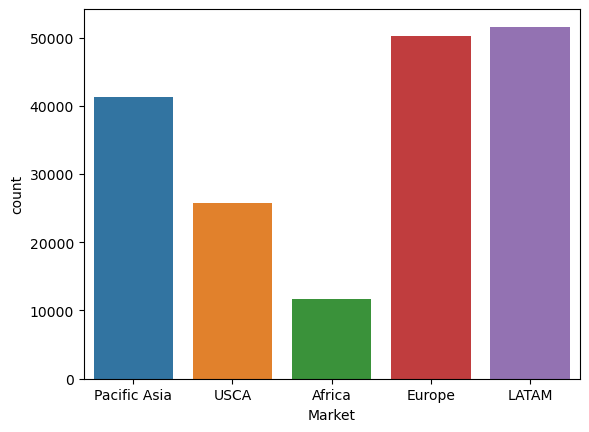

In [41]:
# Visualizing the count of Market
print(df_supply_chainRisk['Market'].value_counts())
ax = sns.countplot(x='Market', data=df_supply_chainRisk)
plt.show()

The chart shows that **LATAM** and **Europe** have the highest transaction counts, followed by **Pacific Asia**, while **USCA** and especially **Africa** record lower volumes. This suggests that the volume of transactions are more heavily concentrated in certain global markets, and these regional differences may influence delivery performance and late delivery risk patterns.


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22]),
 [Text(0, 0, 'Central America'),
  Text(1, 0, 'Western Europe'),
  Text(2, 0, 'South America'),
  Text(3, 0, 'Oceania'),
  Text(4, 0, 'Northern Europe'),
  Text(5, 0, 'Southeast Asia'),
  Text(6, 0, 'Southern Europe'),
  Text(7, 0, 'Caribbean'),
  Text(8, 0, 'West of USA '),
  Text(9, 0, 'South Asia'),
  Text(10, 0, 'Eastern Asia'),
  Text(11, 0, 'East of USA'),
  Text(12, 0, 'West Asia'),
  Text(13, 0, 'US Center '),
  Text(14, 0, 'South of  USA '),
  Text(15, 0, 'Eastern Europe'),
  Text(16, 0, 'West Africa'),
  Text(17, 0, 'North Africa'),
  Text(18, 0, 'East Africa'),
  Text(19, 0, 'Central Africa'),
  Text(20, 0, 'Southern Africa'),
  Text(21, 0, 'Canada'),
  Text(22, 0, 'Central Asia')])

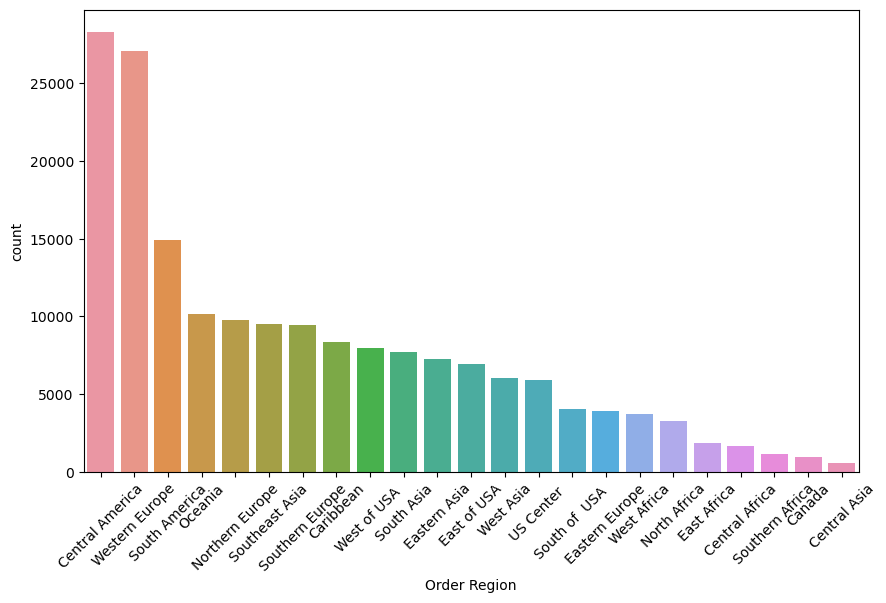

In [42]:
# Visualizing the count of Order Region
plt.figure(figsize=(10,6))
sns.countplot(df_supply_chainRisk['Order Region'],order=df_supply_chainRisk['Order Region'].value_counts().index)
plt.xticks(rotation=45)

The distribution indicates that **Central America** and **Western Europe** have the highest number of orders, followed by **South America** and **Oceania**, while several other regions contribute more moderate or low transaction volumes. This shows that order activity is unevenly distributed across regions, with a few areas accounting for a large share of transactions. Such regional variation may be important in explaining differences in shipping performance and late delivery risk.


(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'COMPLETE'),
  Text(1, 0, 'PENDING_PAYMENT'),
  Text(2, 0, 'PROCESSING'),
  Text(3, 0, 'PENDING'),
  Text(4, 0, 'CLOSED'),
  Text(5, 0, 'ON_HOLD'),
  Text(6, 0, 'SUSPECTED_FRAUD'),
  Text(7, 0, 'CANCELED'),
  Text(8, 0, 'PAYMENT_REVIEW')])

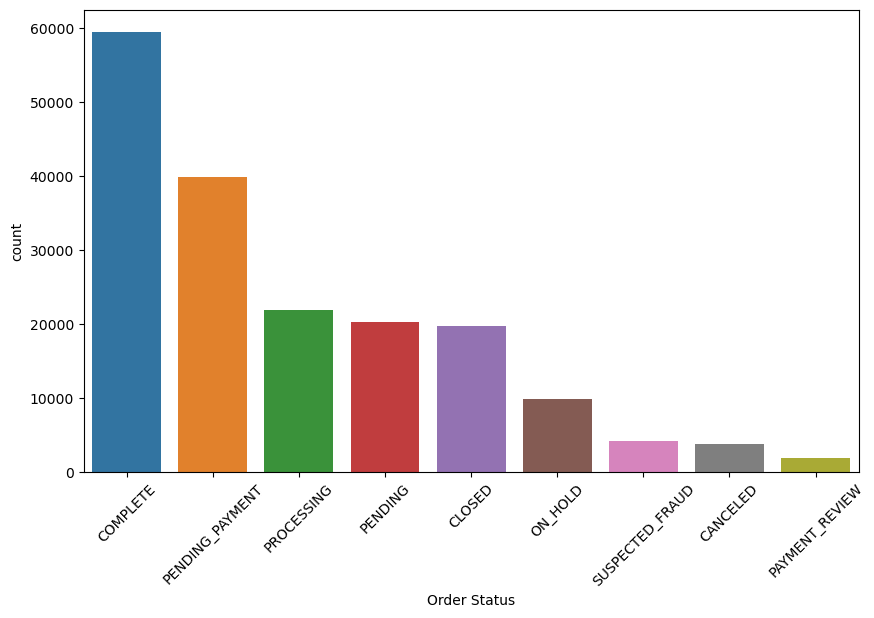

In [43]:
# Visualizing the count of Order Status
plt.figure(figsize=(10,6))
sns.countplot(df_supply_chainRisk['Order Status'],order=df_supply_chainRisk['Order Status'].value_counts().index)
plt.xticks(rotation=45)

The chart shows that **COMPLETE** orders make up the largest share of transactions, followed by **PENDING_PAYMENT**, while statuses such as **PROCESSING**, **PENDING**, and **CLOSED** appear at moderate levels. In contrast, **SUSPECTED_FRAUD**, **CANCELED**, and **PAYMENT_REVIEW** occur much less frequently. This suggests that most orders move through normal completion stages, while fraud-related or canceled cases are relatively low in numbers.


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Standard Class'),
  Text(1, 0, 'Second Class'),
  Text(2, 0, 'First Class'),
  Text(3, 0, 'Same Day')])

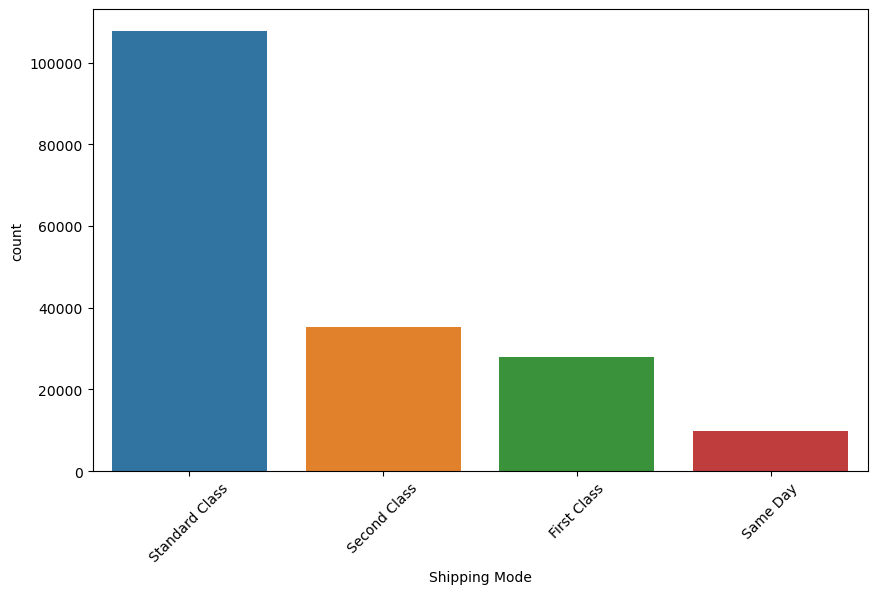

In [44]:
# Visualizing the count of Shipping Order
plt.figure(figsize=(10,6))
sns.countplot(df_supply_chainRisk['Shipping Mode'],order=df_supply_chainRisk['Shipping Mode'].value_counts().index)
plt.xticks(rotation=45)

The chart indicates that **Standard Class** is the most frequently used shipping mode by a wide margin, followed by **Second Class** and **First Class**, while **Same Day** is used the least. This suggests that most deliveries rely on standard shipping options, which may have an important influence on overall delivery timing and late delivery risk.


**Bivariate Analysis**

=== Average Actual Shipping Days (real) ===
Late_delivery_risk
0    2.779561
1    4.089253
Name: Days for shipping (real), dtype: float64


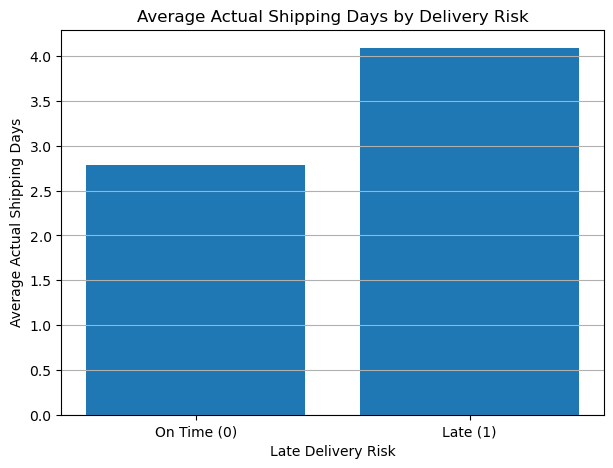

In [45]:
# Compute average actual shipping days grouped by late vs on-time
avg_actual_days = df_supply_chainRisk.groupby("Late_delivery_risk")["Days for shipping (real)"].mean()

print("=== Average Actual Shipping Days (real) ===")
print(avg_actual_days)

# Plot
plt.figure(figsize=(7,5))
plt.bar(["On Time (0)", "Late (1)"], avg_actual_days.values)
plt.xlabel("Late Delivery Risk")
plt.ylabel("Average Actual Shipping Days")
plt.title("Average Actual Shipping Days by Delivery Risk")
plt.grid(axis="y")
plt.show()

The chart shows that orders classified as **late delivery risk (1)** have a higher average actual shipping time than **on-time deliveries (0)**. This indicates a clear relationship between longer shipping duration and the likelihood of late delivery.There is a big gap, hence, Late shipments take about 1.3 days longer on average, suggesting that **actual shipping days** are an **important predictor** of delivery risk.


=== Average Scheduled Shipping Days ===
Late_delivery_risk
0    3.491146
1    2.471069
Name: Days for shipment (scheduled), dtype: float64


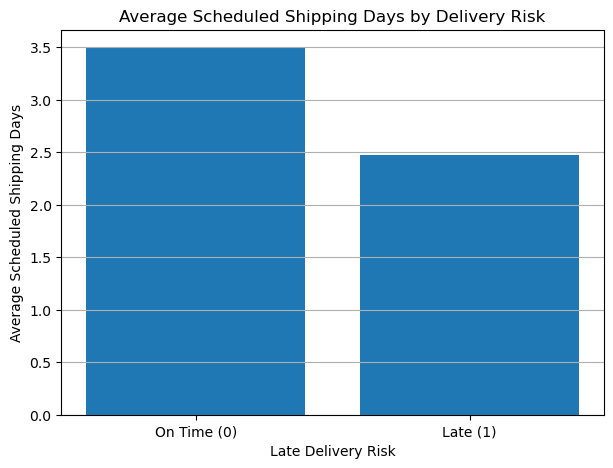

In [46]:
# Lets Compute the average scheduled shipping days for each risk group
avg_scheduled_days = df_supply_chainRisk.groupby("Late_delivery_risk")["Days for shipment (scheduled)"].mean()

print("=== Average Scheduled Shipping Days ===")
print(avg_scheduled_days)

# Plot
plt.figure(figsize=(7,5))
plt.bar(["On Time (0)", "Late (1)"], avg_scheduled_days.values)
plt.xlabel("Late Delivery Risk")
plt.ylabel("Average Scheduled Shipping Days")
plt.title("Average Scheduled Shipping Days by Delivery Risk")
plt.grid(axis="y")
plt.show()

The chart indicates that orders labeled as **late delivery risk (1)** have fewer average scheduled shipping days than **on-time deliveries (0)**. This suggests that tighter planned delivery windows may be associated with a higher chance of delay, making scheduled shipping time an important factor in late delivery risk.


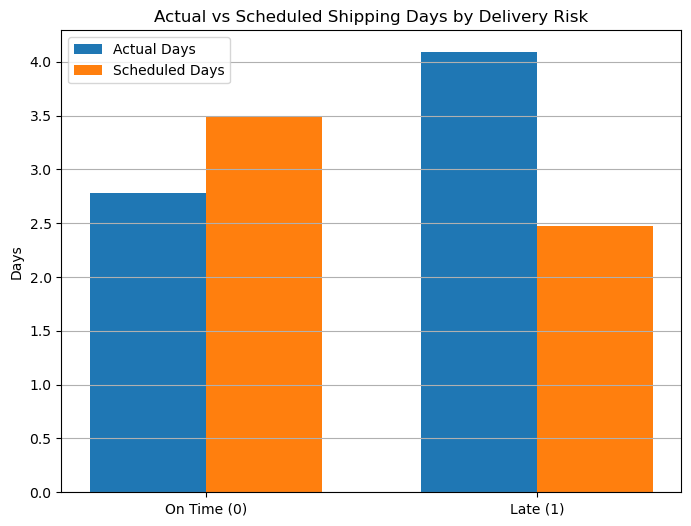

In [47]:
# Compute averages
avg_actual = df_supply_chainRisk.groupby("Late_delivery_risk")["Days for shipping (real)"].mean()
avg_scheduled = df_supply_chainRisk.groupby("Late_delivery_risk")["Days for shipment (scheduled)"].mean()

# Lets Create side-by-side bar chart
labels = ["On Time (0)", "Late (1)"]
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,6))
plt.bar(x - width/2, avg_actual.values, width, label="Actual Days")
plt.bar(x + width/2, avg_scheduled.values, width, label="Scheduled Days")

plt.xticks(x, labels)
plt.ylabel("Days")
plt.title("Actual vs Scheduled Shipping Days by Delivery Risk")
plt.legend()
plt.grid(axis="y")
plt.show()

The chart shows a clear contrast between actual and scheduled shipping days across delivery outcomes. For **on-time deliveries (0)**, actual shipping days are lower than scheduled days, while for **late deliveries (1)**, actual shipping days exceed scheduled days. This indicates that late deliveries occur when shipments take longer than planned, making the gap between actual and scheduled shipping time a strong indicator of delivery risk.


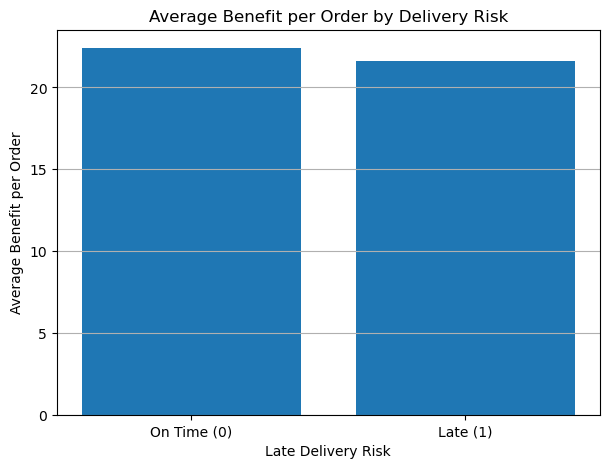

In [48]:
# Compute averages for benefit per order
avg_benefit = df_supply_chainRisk.groupby("Late_delivery_risk")["Benefit per order"].mean()

# Visualization
plt.figure(figsize=(7,5))
plt.bar(["On Time (0)", "Late (1)"], avg_benefit.values)
plt.xlabel("Late Delivery Risk")
plt.ylabel("Average Benefit per Order")
plt.title("Average Benefit per Order by Delivery Risk")
plt.grid(axis="y")
plt.show()

The chart shows that **on-time deliveries (0)** have a slightly higher average benefit per order than **late deliveries (1)**. This suggests that delayed deliveries may be associated with a small reduction in order-level profitability, although the difference appears modest.


Mean Sales per Customer: 183.10760850793417
Max Sales per Customer: 1939.98999


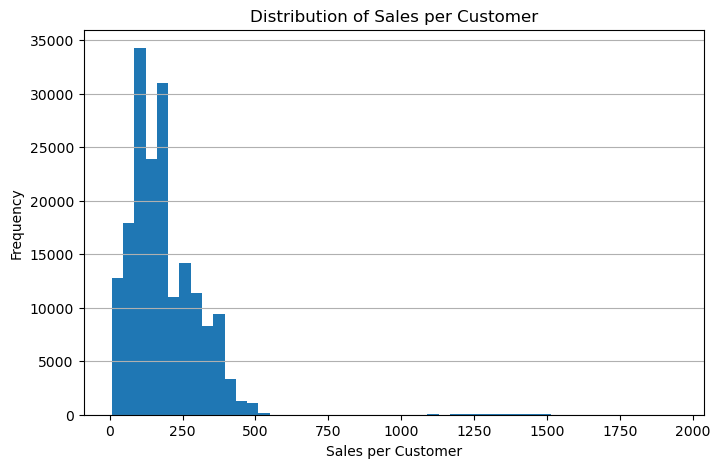

In [49]:
# Extract the column
sales = df_supply_chainRisk["Sales per customer"]

# Compute Stats
mean_sales = sales.mean()
max_sales = sales.max()

print("Mean Sales per Customer:", mean_sales)
print("Max Sales per Customer:", max_sales)

# Plot distribution
plt.figure(figsize=(8,5))
plt.hist(sales, bins=50)
plt.xlabel("Sales per Customer")
plt.ylabel("Frequency")
plt.title("Distribution of Sales per Customer")
plt.grid(axis="y")
plt.show()

The distribution of **sales per customer** is positively skewed, with most customers generating relatively low to moderate sales values and a small number contributing very high sales. This suggests that customer spending is unevenly distributed, with a few high-value customers acting as outliers.


Minimum Product Price: 9.989999771
Maximum Product Price: 1999.98999


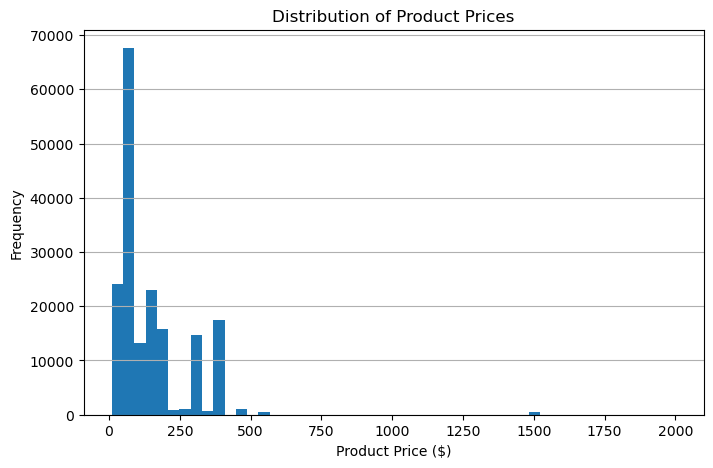

In [50]:
# Lets Extract Product Price column
prices = df_supply_chainRisk["Product Price"]

# Compute range
min_price = prices.min()
max_price = prices.max()

print("Minimum Product Price:", min_price)
print("Maximum Product Price:", max_price)

# Plot distribution
plt.figure(figsize=(8,5))
plt.hist(prices, bins=50)
plt.xlabel("Product Price ($)")
plt.ylabel("Frequency")
plt.title("Distribution of Product Prices")
plt.grid(axis="y")
plt.show()

The distribution of **product prices** is heavily right-skewed, with most products concentrated in the lower price range and a few products priced much higher. This indicates that there are many low to moderately priced items, while the high-priced products appear as relatively rare outliers.


Late_delivery_risk      0      1
Delivery Status                 
Advance shipping    41592      0
Late delivery           0  98977
Shipping canceled    7754      0
Shipping on time    32196      0


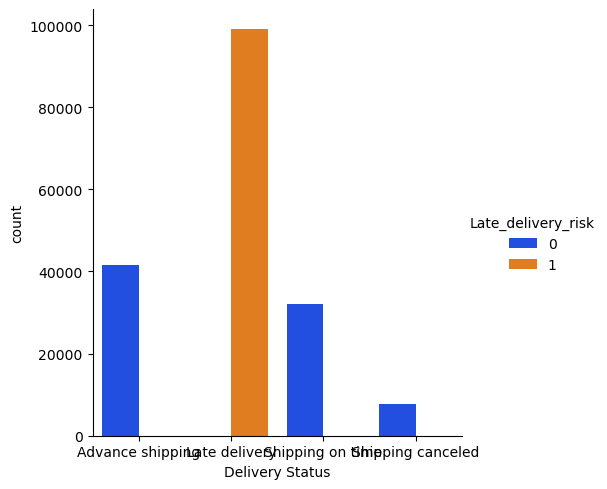

In [51]:
# Checking Delivery Status vs Late_delivery_risk
print(pd.crosstab(df_supply_chainRisk['Delivery Status'],df_supply_chainRisk['Late_delivery_risk']))
sns.catplot(x = 'Delivery Status', hue = 'Late_delivery_risk', palette = "bright", kind = "count", data = df_supply_chainRisk)
plt.show()

This chart shows a strong alignment between **delivery status** and **late delivery risk**. Transactions marked as **late delivery** are almost entirely associated with **high risk (1)**, while **advance shipping**, **shipping on time**, and most **shipping canceled** cases are associated with **low risk (0)**. As shown above, close to **99,000** shipments were late, which is significant in portion an indicates that delivery status is a highly informative feature for distinguishing late delivery outcomes.


**Customer Country and Late_delivery_risk**

Late_delivery_risk      0      1
Customer Country                
EE. UU.             50160  60986
Puerto Rico         31382  37991


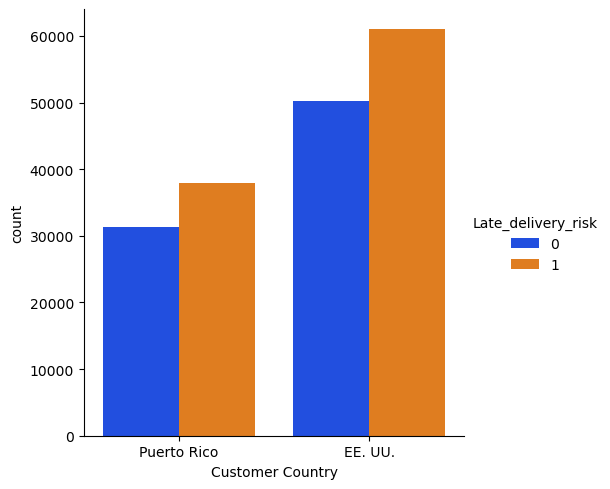

In [52]:
# Checking Customer country vs Late_delivery_risk
print(pd.crosstab(df_supply_chainRisk['Customer Country'],df_supply_chainRisk['Late_delivery_risk']))
sns.catplot(x = 'Customer Country', hue = 'Late_delivery_risk', palette = "bright", kind = "count", data = df_supply_chainRisk)
plt.show()

Late_delivery_risk      0      1
Customer Segment                
Consumer            42256  51248
Corporate           24807  29982
Home Office         14479  17747


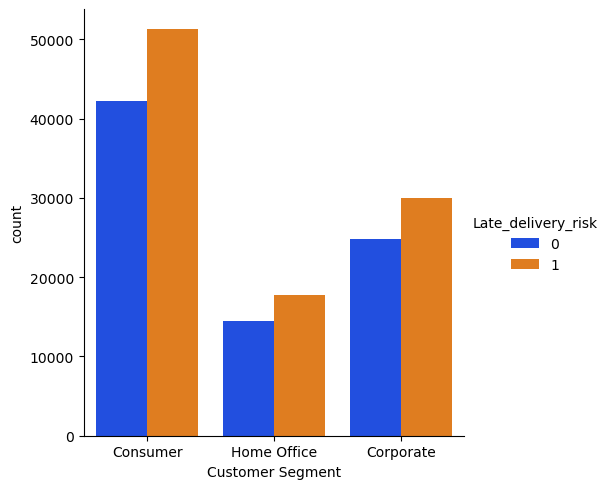

In [53]:
# Checking Customer Segment vs Late_delivery_risk
print(pd.crosstab(df_supply_chainRisk['Customer Segment'],df_supply_chainRisk['Late_delivery_risk']))
sns.catplot(x = 'Customer Segment', hue = 'Late_delivery_risk', palette = "bright", kind = "count", data = df_supply_chainRisk)
plt.show()

The chart shows that both **EE. UU.** and **Puerto Rico** have more **late delivery risk cases (1)** than **on-time cases (0)**. The United States records the highest volume in both categories, while Puerto Rico also shows a substantial number of late deliveries. This suggests that late delivery risk is common across both customer locations, though it is more pronounced in the higher-volume U.S. market.


Late_delivery_risk      0      1
Market                          
Africa               5274   6340
Europe              22509  27743
LATAM               23550  28044
Pacific Asia        18548  22712
USCA                11661  14138


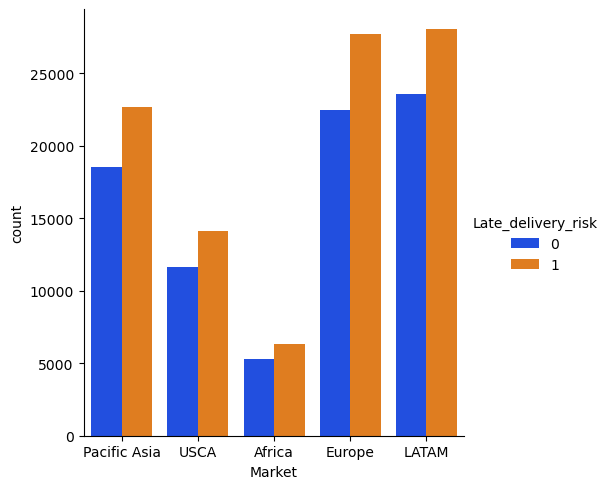

In [54]:
# Checking Market vs Late_delivery_risk
print(pd.crosstab(df_supply_chainRisk['Market'],df_supply_chainRisk['Late_delivery_risk']))
sns.catplot(x = 'Market', hue = 'Late_delivery_risk', palette = "bright", kind = "count", data = df_supply_chainRisk)
plt.show()

The chart shows that **late delivery risk (1)** is higher than **on-time delivery (0)** across all markets. **LATAM** and **Europe** record the largest volumes in both categories, while **Africa** has the lowest. This suggests that late delivery is a consistent pattern across regions.


Late_delivery_risk      0      1
Shipping Mode                   
First Class          1301  26513
Same Day             5283   4454
Second Class         8229  26987
Standard Class      66729  41023


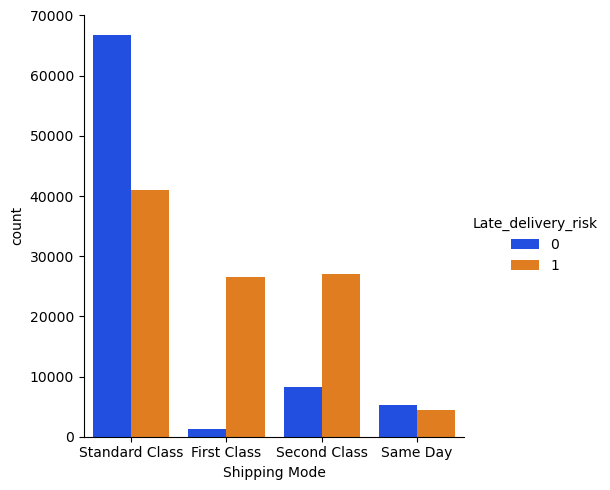

In [55]:
# Checking Shipping Mode vs Late_delivery_risk
print(pd.crosstab(df_supply_chainRisk['Shipping Mode'],df_supply_chainRisk['Late_delivery_risk']))
sns.catplot(x = 'Shipping Mode', hue = 'Late_delivery_risk', palette = "bright", kind = "count", data = df_supply_chainRisk)
plt.show()

The above chart shows that **late delivery risk is especially high for First Class and Second Class shipments**, where delayed cases exceed on-time cases by a wide margin. In contrast, **Standard Class** has more on-time deliveries than late ones, while **Same Day** appears relatively balanced. This suggests that shipping mode has a strong influence on delivery outcomes, with some service classes showing much greater delay risk than others.


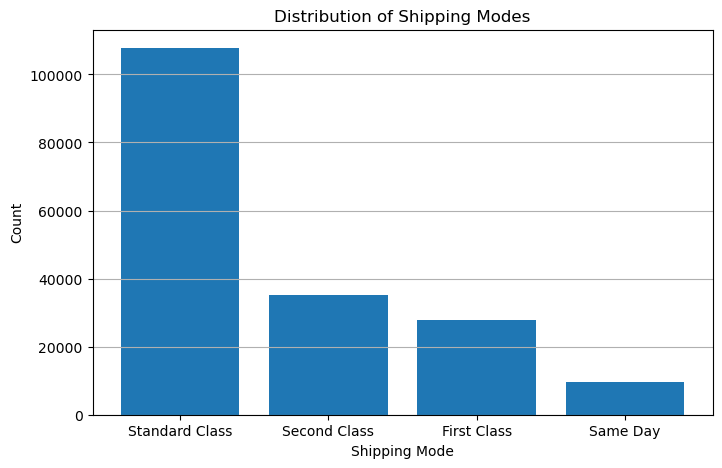

In [56]:
# Count shipping modes
mode_counts = df_supply_chainRisk["Shipping Mode"].value_counts()

# Bar Chart
plt.figure(figsize=(8,5))
plt.bar(mode_counts.index, mode_counts.values)
plt.xlabel("Shipping Mode")
plt.ylabel("Count")
plt.title("Distribution of Shipping Modes")
plt.grid(axis="y")
plt.show()

This distribution shows that **Standard Class** is used far more than any other shipping option, while **Second Class** and **First Class** appear at moderate levels and **Same Day** is the least used. This indicates that standard shipping dominates the available options and is likely a major driver of overall delivery performance patterns.


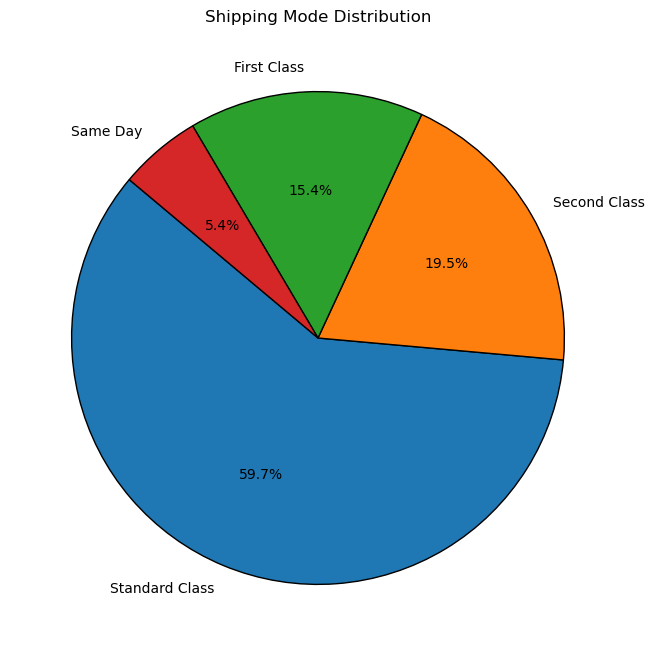

In [57]:
# Count shipping modes
mode_counts = df_supply_chainRisk["Shipping Mode"].value_counts()

# Pie chart
plt.figure(figsize=(8,8))
plt.pie(
    mode_counts.values,
    labels=mode_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "black"}
)

plt.title("Shipping Mode Distribution")
plt.show()

The above pie chart confirms that **Standard Class** accounts for the majority of shipments at **59.7%**, followed by **Second Class (19.5%)** and **First Class (15.4%)**, while **Same Day** represents only **5.4%**. This shows that most orders rely on standard shipping, making it the most influential shipping mode.


### Correlation Analysis

**Correlation between Target variable and Independent Variables.**

In [58]:
# Checking the correlation between features and the target.
cor = df_supply_chainRisk.corr()
cor

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Department Id,Latitude,Longitude,Order Item Discount,...,Order Item Total,Order Profit Per Order,Product Price,delay_gap,is_tight_schedule,shipping_mode_risk,category_risk,market_risk,ship_month,ship_weekday
Days for shipping (real),1.000000,0.515880,-0.005101,0.001757,0.401415,-0.000348,-0.001631,-0.004073,3.910686e-03,0.002231,...,0.001757,-0.005101,0.002185,0.613475,-0.373409,-2.910560e-01,-0.001739,-0.004559,-0.006459,0.001022
Days for shipment (scheduled),0.515880,1.000000,-0.000185,0.006445,-0.369352,-0.000367,-0.000262,-0.005300,3.675392e-03,0.002897,...,0.006445,-0.000185,0.006912,-0.360037,-0.945696,-8.080507e-01,-0.015367,-0.009322,-0.005662,0.007037
Benefit per order,-0.005101,-0.000185,1.000000,0.133484,-0.003727,0.031889,0.031442,0.000338,-2.520708e-03,0.064756,...,0.133484,1.000000,0.103459,-0.005385,-0.000282,1.945274e-03,-0.016584,0.003055,0.008307,0.001242
Sales per customer,0.001757,0.006445,0.133484,1.000000,-0.003791,0.225201,0.232367,-0.000223,1.443660e-03,0.498734,...,1.000000,0.133484,0.781781,-0.004028,-0.005834,-2.203104e-03,-0.136957,0.041447,0.024478,-0.002042
Late_delivery_risk,0.401415,-0.369352,-0.003727,-0.003791,1.000000,0.001752,0.001077,0.000679,-1.914878e-03,-0.000750,...,-0.003791,-0.003727,-0.002175,0.777644,0.409749,4.570899e-01,0.015414,0.006923,0.003177,-0.004108
Category Id,-0.000348,-0.000367,0.031889,0.225201,0.001752,1.000000,0.888835,0.002195,-2.319861e-03,0.140180,...,0.225201,0.031889,0.461059,-0.000040,0.000321,-3.728166e-04,0.108022,0.081349,0.036063,0.003258
Department Id,-0.001631,-0.000262,0.031442,0.232367,0.001077,0.888835,1.000000,0.002460,-2.434644e-03,0.144617,...,0.232367,0.031442,0.446743,-0.001534,-0.000134,-6.441238e-05,0.063139,0.044051,0.021338,0.008274
Latitude,-0.004073,-0.005300,0.000338,-0.000223,0.000679,0.002195,0.002460,1.000000,-5.251224e-01,-0.002997,...,-0.000223,0.000338,0.000471,0.000450,0.004957,4.179076e-04,0.001930,-0.006328,-0.002305,-0.002234
Longitude,0.003911,0.003675,-0.002521,0.001444,-0.001915,-0.002320,-0.002435,-0.525122,1.000000e+00,0.002343,...,0.001444,-0.002521,-0.000894,0.000871,-0.002387,6.096385e-09,0.000470,0.001602,0.001929,-0.004839
Order Item Discount,0.002231,0.002897,0.064756,0.498734,-0.000750,0.140180,0.144617,-0.002997,2.342837e-03,1.000000,...,0.498734,0.064756,0.488101,-0.000241,-0.001829,-3.573414e-04,-0.083874,0.026186,0.014795,0.000958


In [59]:
# Checking the correlation again.
cor = df_supply_chainRisk.corr()
cor

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Department Id,Latitude,Longitude,Order Item Discount,...,Order Item Total,Order Profit Per Order,Product Price,delay_gap,is_tight_schedule,shipping_mode_risk,category_risk,market_risk,ship_month,ship_weekday
Days for shipping (real),1.000000,0.515880,-0.005101,0.001757,0.401415,-0.000348,-0.001631,-0.004073,3.910686e-03,0.002231,...,0.001757,-0.005101,0.002185,0.613475,-0.373409,-2.910560e-01,-0.001739,-0.004559,-0.006459,0.001022
Days for shipment (scheduled),0.515880,1.000000,-0.000185,0.006445,-0.369352,-0.000367,-0.000262,-0.005300,3.675392e-03,0.002897,...,0.006445,-0.000185,0.006912,-0.360037,-0.945696,-8.080507e-01,-0.015367,-0.009322,-0.005662,0.007037
Benefit per order,-0.005101,-0.000185,1.000000,0.133484,-0.003727,0.031889,0.031442,0.000338,-2.520708e-03,0.064756,...,0.133484,1.000000,0.103459,-0.005385,-0.000282,1.945274e-03,-0.016584,0.003055,0.008307,0.001242
Sales per customer,0.001757,0.006445,0.133484,1.000000,-0.003791,0.225201,0.232367,-0.000223,1.443660e-03,0.498734,...,1.000000,0.133484,0.781781,-0.004028,-0.005834,-2.203104e-03,-0.136957,0.041447,0.024478,-0.002042
Late_delivery_risk,0.401415,-0.369352,-0.003727,-0.003791,1.000000,0.001752,0.001077,0.000679,-1.914878e-03,-0.000750,...,-0.003791,-0.003727,-0.002175,0.777644,0.409749,4.570899e-01,0.015414,0.006923,0.003177,-0.004108
Category Id,-0.000348,-0.000367,0.031889,0.225201,0.001752,1.000000,0.888835,0.002195,-2.319861e-03,0.140180,...,0.225201,0.031889,0.461059,-0.000040,0.000321,-3.728166e-04,0.108022,0.081349,0.036063,0.003258
Department Id,-0.001631,-0.000262,0.031442,0.232367,0.001077,0.888835,1.000000,0.002460,-2.434644e-03,0.144617,...,0.232367,0.031442,0.446743,-0.001534,-0.000134,-6.441238e-05,0.063139,0.044051,0.021338,0.008274
Latitude,-0.004073,-0.005300,0.000338,-0.000223,0.000679,0.002195,0.002460,1.000000,-5.251224e-01,-0.002997,...,-0.000223,0.000338,0.000471,0.000450,0.004957,4.179076e-04,0.001930,-0.006328,-0.002305,-0.002234
Longitude,0.003911,0.003675,-0.002521,0.001444,-0.001915,-0.002320,-0.002435,-0.525122,1.000000e+00,0.002343,...,0.001444,-0.002521,-0.000894,0.000871,-0.002387,6.096385e-09,0.000470,0.001602,0.001929,-0.004839
Order Item Discount,0.002231,0.002897,0.064756,0.498734,-0.000750,0.140180,0.144617,-0.002997,2.342837e-03,1.000000,...,0.498734,0.064756,0.488101,-0.000241,-0.001829,-3.573414e-04,-0.083874,0.026186,0.014795,0.000958


The above reveals the correlation between the dependent and independent variables. We shall illustrate this relationship by generating a heatmap plot.

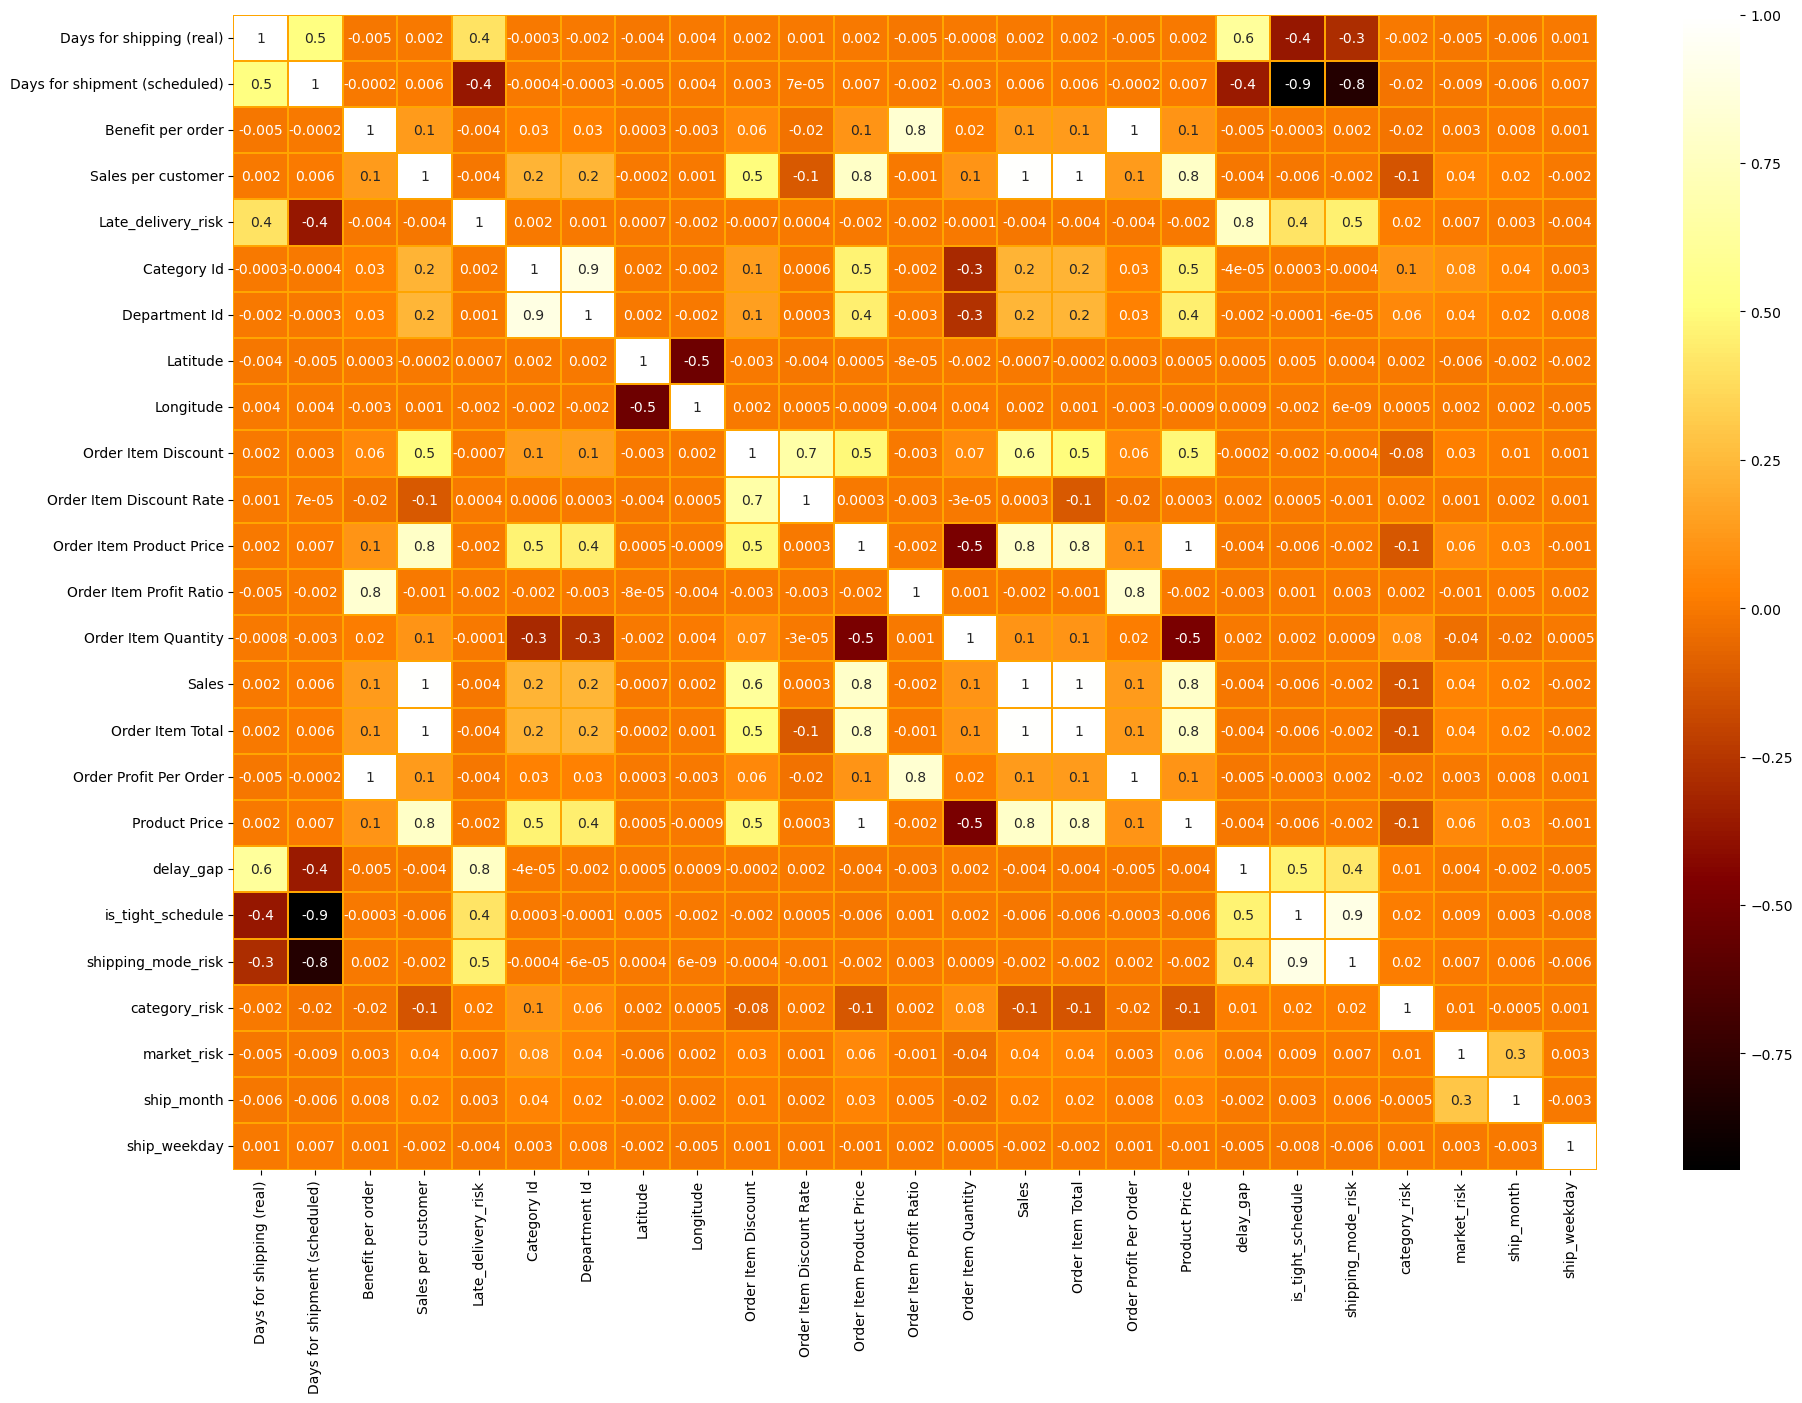

In [60]:
# Visualizing the correlation matrix by plotting heatmap
plt.figure(figsize = (22, 15))
sns.heatmap(df_supply_chainRisk.corr(), linewidths = 0.1, fmt = ".1g", linecolor = "Orange", annot = True, cmap = "afmhot")
plt.yticks(rotation = 0);
plt.show()

*  **0- no relation, -0.3 to +0.3- less correlation, greater than -0.5 or greater than +0.5- moderate correlation, greater than -0.7**

The correlation heatmap shows that **late delivery risk** is most strongly associated with shipping-related variables, especially **'delay_gap'**, **'shipping_mode_risk'**, **'Days for shipping(real)'**, and **'is_tight_schedule'**. In contrast, most pricing, sales, geographic, and profit-related variables have very weak correlations with the target. This suggests that late delivery is driven mainly by **operational shipping conditions** rather than **customer spending** or **financial factors**.


In [61]:
# Computing the correlation of all numeric columns with Target

df_supply_chainRisk.corr()['Late_delivery_risk'].sort_values(ascending = False)

Late_delivery_risk               1.000000
delay_gap                        0.777644
shipping_mode_risk               0.457090
is_tight_schedule                0.409749
Days for shipping (real)         0.401415
category_risk                    0.015414
market_risk                      0.006923
ship_month                       0.003177
Category Id                      0.001752
Department Id                    0.001077
Latitude                         0.000679
Order Item Discount Rate         0.000404
Order Item Quantity             -0.000139
Order Item Discount             -0.000750
Longitude                       -0.001915
Product Price                   -0.002175
Order Item Product Price        -0.002175
Order Item Profit Ratio         -0.002316
Sales                           -0.003564
Benefit per order               -0.003727
Order Profit Per Order          -0.003727
Order Item Total                -0.003791
Sales per customer              -0.003791
ship_weekday                    -0

**Days for shipping (real)** have the strongest positive relationship with the Late_delivery_risk, while **Days for shipment (scheduled)** have most negative correlations.

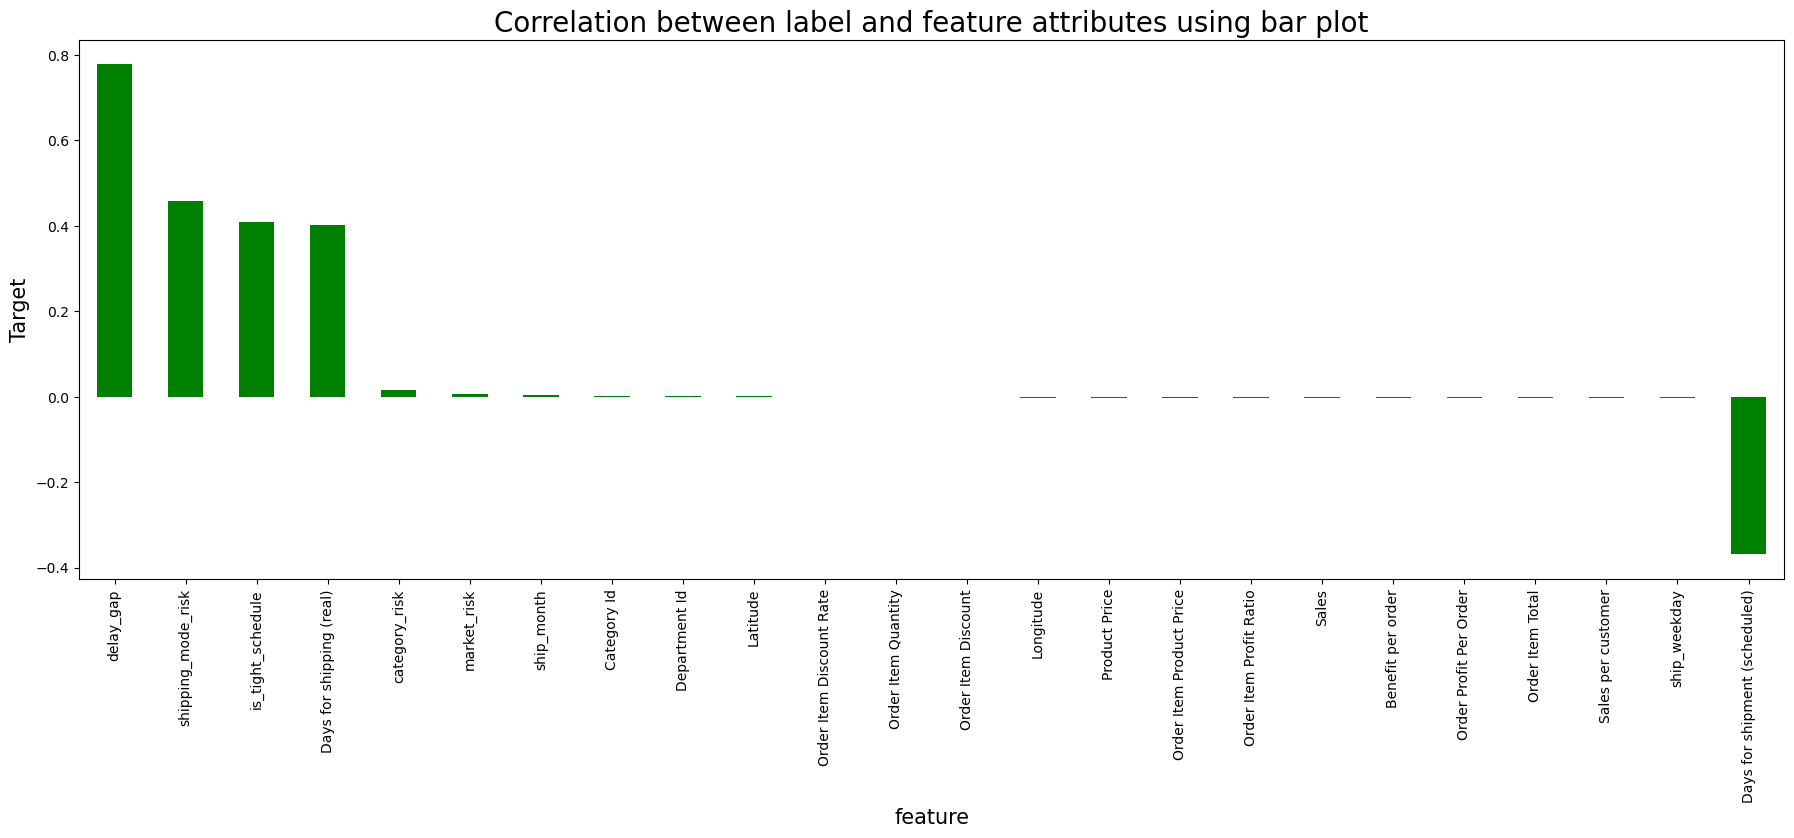

In [62]:
plt.figure(figsize = (22, 7))
df_supply_chainRisk.corr()['Late_delivery_risk'].sort_values(ascending = False).drop(['Late_delivery_risk']).plot(kind='bar',color="g")
plt.xlabel('feature', fontsize = 15)
plt.ylabel('Target', fontsize = 15)
plt.title("Correlation between label and feature attributes using bar plot", fontsize=20)
plt.show()

The bar plot confirms that **delay_gap** has the strongest positive relationship with the target, followed by **shipping_mode_risk**, **is_tight_schedule**, and **actual shipping days**. Meanwhile, **scheduled shipping days** show a notable negative relationship, while most other features have very weak correlations. This indicates that late delivery risk is driven primarily by shipping timing and schedule-related factors rather than sales, profit, or product-level variables.


### Detect the Outliers (IQR Method)

We will check the four(4) relevant variables:

* Days for shipping (real) → no outliers

* Days for shipment (scheduled) → no outliers

* Benefit per order → outliers present

* Sales per customer → long tail/outliers present

In [63]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers, lower_bound, upper_bound

# Variables
out_real, lb_real, ub_real = detect_outliers_iqr(df_supply_chainRisk["Days for shipping (real)"])
out_sched, lb_sched, ub_sched = detect_outliers_iqr(df_supply_chainRisk["Days for shipment (scheduled)"])
out_benefit, lb_bef, ub_bef = detect_outliers_iqr(df_supply_chainRisk["Benefit per order"])
out_sales, lb_sales, ub_sales = detect_outliers_iqr(df_supply_chainRisk["Sales per customer"])

print("Real shipping days outliers:", len(out_real))
print("Scheduled days outliers:", len(out_sched))
print("Benefit per order outliers:", len(out_benefit))
print("Sales per customer outliers:", len(out_sales))

Real shipping days outliers: 0
Scheduled days outliers: 0
Benefit per order outliers: 18942
Sales per customer outliers: 1943


**Visualize Outliers with Boxplots**

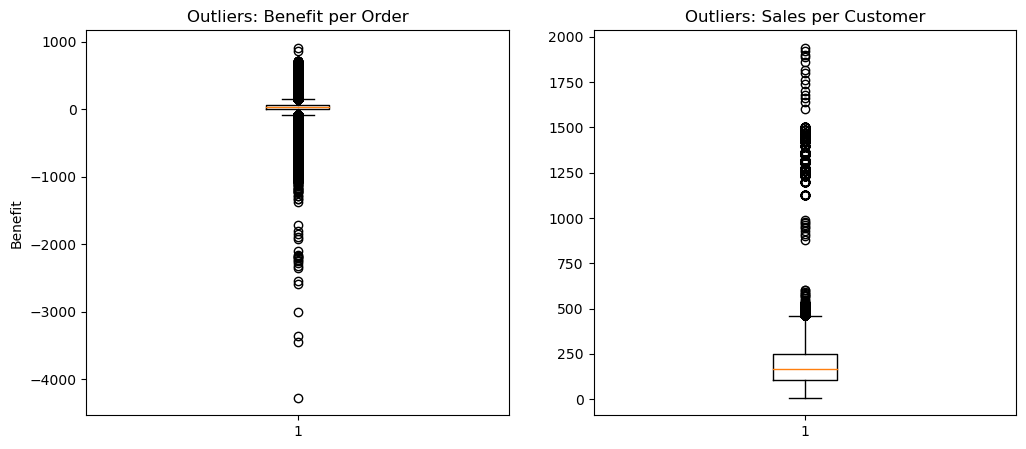

In [64]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.boxplot(df_supply_chainRisk["Benefit per order"])
plt.title("Outliers: Benefit per Order")
plt.ylabel("Benefit")

plt.subplot(1,2,2)
plt.boxplot(df_supply_chainRisk["Sales per customer"])
plt.title("Outliers: Sales per Customer")

plt.show()

**Remove OR Winsorize Outliers**

Since these outliers do not break the model but can distort scaling/regression, the best practice is Winsorization (capping extreme values).

We will NOT remove outliers for shipping days because they have no outlier problem.

**Winsorization the Outliers**

In [65]:
def winsorize(series, lower_quantile=0.01, upper_quantile=0.99):
    lower = series.quantile(lower_quantile)
    upper = series.quantile(upper_quantile)
    return series.clip(lower, upper)

Applying Winsorization ONLY to Benefit & Sales

In [66]:
df_supply_chainRisk["Benefit per order"] = winsorize(df_supply_chainRisk["Benefit per order"])
df_supply_chainRisk["Sales per customer"] = winsorize(df_supply_chainRisk["Sales per customer"])

This is to cap only extreme values while keeping the distribution realistic.

**Check Removal of Outliers**

In [67]:
# Recheck after winsorization
out_benefit2, _, _ = detect_outliers_iqr(df_supply_chainRisk["Benefit per order"])
out_sales2, _, _ = detect_outliers_iqr(df_supply_chainRisk["Sales per customer"])

print("Benefit outliers after cleaning:", len(out_benefit2))
print("Sales outliers after cleaning:", len(out_sales2))

Benefit outliers after cleaning: 18942
Sales outliers after cleaning: 1943


In [68]:
def winsorize(series, lower_quantile=0.05, upper_quantile=0.95):
    lower = series.quantile(lower_quantile)
    upper = series.quantile(upper_quantile)
    return series.clip(lower, upper)

df_supply_chainRisk["Benefit per order"] = winsorize(df_supply_chainRisk["Benefit per order"])
df_supply_chainRisk["Sales per customer"] = winsorize(df_supply_chainRisk["Sales per customer"])

In [69]:
# Recheck outliers
out_benefit2, _, _ = detect_outliers_iqr(df_supply_chainRisk["Benefit per order"])
out_sales2, _, _ = detect_outliers_iqr(df_supply_chainRisk["Sales per customer"])

print("Benefit outliers after 5-95 cleaning:", len(out_benefit2))
print("Sales outliers after 5-95 cleaning:", len(out_sales2))

Benefit outliers after 5-95 cleaning: 13727
Sales outliers after 5-95 cleaning: 0


In [70]:
df = df_supply_chainRisk.drop(columns=["Benefit per order"])
print(df.head())

       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Sales per customer   Delivery Status  Late_delivery_risk  Category Id  \
0          314.640015  Advance shipping                   0           73   
1          311.359985     Late delivery                   1           73   
2          309.720001  Shipping on time                   0           73   
3          304.809998  Advance shipping                   0           73   
4          298.250000  Advance shipping                   0           73   

    Category Name Customer City Customer Country  ...  Product Name  \
0  Sporting Goods        Caguas      Pu

In [71]:
# Create the delay_gap feature
df_supply_chainRisk["delay_gap"] = df["Days for shipping (real)"] - df_supply_chainRisk["Days for shipment (scheduled)"]

# Preview result
print(df_supply_chainRisk[["Days for shipping (real)", "Days for shipment (scheduled)", "delay_gap"]].head())

   Days for shipping (real)  Days for shipment (scheduled)  delay_gap
0                         3                              4         -1
1                         5                              4          1
2                         4                              4          0
3                         3                              4         -1
4                         2                              4         -2


In [72]:
# Creating delay_gap
df_supply_chainRisk["delay_gap"] = df_supply_chainRisk["Days for shipping (real)"] - df_supply_chainRisk["Days for shipment (scheduled)"]

# Statistical summary
print("=== Statistical Summary of delay_gap ===")
print(df_supply_chainRisk["delay_gap"].describe())

=== Statistical Summary of delay_gap ===
count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: delay_gap, dtype: float64


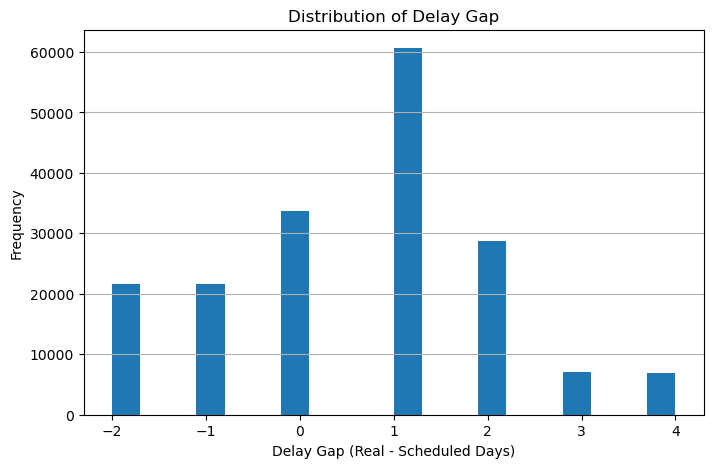

In [73]:
# Histogram of delay_gap
plt.figure(figsize=(8,5))
plt.hist(df_supply_chainRisk["delay_gap"], bins=20)
plt.xlabel("Delay Gap (Real - Scheduled Days)")
plt.ylabel("Frequency")
plt.title("Distribution of Delay Gap")
plt.grid(axis="y")
plt.show()

The delay gap distribution is centered mostly around **positive(+ve) values**, especially **1 day**, indicating that many shipments took longer than their scheduled delivery time. **Negative(-ve)** values are also present, showing that some orders were delivered earlier than expected, but these occur less often. Overall, the pattern suggests that delivery delays are more common than early deliveries in the dataset.


### Feature Engineering & Preprocessing

**Feature Scaling using standard scalarization**

In [74]:
x = df_supply_chainRisk.drop("Late_delivery_risk", axis =1)
y = df_supply_chainRisk["Late_delivery_risk"]

In [75]:
# Encode categorical columns
x_encoded = x.copy()
for col in x_encoded.select_dtypes(include=['object']).columns:
    x_encoded[col] = LabelEncoder().fit_transform(x_encoded[col])

In [76]:
# Scale the encoded data
scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x_encoded), columns=x_encoded.columns)

x_scaled.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Category Id,Category Name,Customer City,Customer Country,...,Product Name,Product Price,Shipping Mode,delay_gap,is_tight_schedule,shipping_mode_risk,category_risk,market_risk,ship_month,ship_weekday
0,-0.678772,-0.306491,0.777152,1.005140,1.352958,-1.194539,2.630978,0.930534,-0.795294,1.265761,...,0.829945,1.334822,0.695051,-1.050199,-0.821778,-0.736667,0.825264,0.629645,-0.976887,0.501167
1,1.331997,0.925251,0.777152,-2.685867,1.320119,-0.172916,2.630978,0.930534,-0.795294,1.265761,...,0.829945,1.334822,0.695051,0.291216,-0.821778,-0.736667,0.825264,0.629645,-1.561319,0.002035
2,-1.684156,0.309380,0.777152,-2.685867,1.303699,1.870329,2.630978,0.930534,1.603264,-0.790039,...,0.829945,1.334822,0.695051,-0.379492,-0.821778,-0.736667,0.825264,0.629645,-1.561319,-0.497096
3,-0.678772,-0.306491,0.777152,-0.089988,1.254542,-1.194539,2.630978,0.930534,0.565546,-0.790039,...,0.829945,1.334822,0.695051,-1.050199,-0.821778,-0.736667,0.825264,0.629645,-1.561319,-0.996228
4,0.326612,-0.922361,0.777152,1.662312,1.188864,-1.194539,2.630978,0.930534,-0.795294,1.265761,...,0.829945,1.334822,0.695051,-1.720907,-0.821778,-0.736667,0.825264,0.629645,-1.561319,-1.495360


In [77]:
x_scaled.tail()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Category Id,Category Name,Customer City,Customer Country,...,Product Name,Product Price,Shipping Mode,delay_gap,is_tight_schedule,shipping_mode_risk,category_risk,market_risk,ship_month,ship_weekday
180514,-1.684156,0.309380,0.777152,0.184475,2.047175,1.870329,0.840699,-0.618292,-0.838791,-0.790039,...,-1.469431,1.85174,0.695051,-0.379492,-0.821778,-0.736667,0.126811,0.629645,-1.561319,-0.497096
180515,-0.678772,-0.306491,-0.677980,-2.685867,2.047175,-0.172916,0.840699,-0.618292,-1.043849,-0.790039,...,-1.469431,1.85174,-0.213283,0.291216,1.216874,0.958501,0.126811,0.629645,-1.561319,-0.996228
180516,1.331997,0.925251,0.777152,1.662312,2.047175,-0.172916,0.840699,-0.618292,-0.863646,-0.790039,...,-1.469431,1.85174,0.695051,0.291216,-0.821778,-0.736667,0.126811,0.629645,-1.561319,-0.497096
180517,0.326612,-0.306491,0.777152,1.662312,2.047175,-1.194539,0.840699,-0.618292,-0.795294,1.265761,...,-1.469431,1.85174,0.695051,-1.050199,-0.821778,-0.736667,0.126811,0.629645,-1.561319,-1.495360
180518,0.326612,0.309380,0.777152,1.662312,2.047175,1.870329,0.840699,-0.618292,-0.795294,1.265761,...,-1.469431,1.85174,0.695051,-0.379492,-0.821778,-0.736667,0.126811,0.629645,-1.561319,-0.996228


We applied the Standard Scalarization method to the data in order to mitigate potential biases and ensure data integrity.

**Checking Variance Inflation Factor(VIF)**

In [78]:
# Lets Start with a copy
X = x.copy()   # your feature DataFrame

In [79]:
# Inspect dtypes and non-numeric columns
print("Column dtypes:\n", X.dtypes)
non_numeric = X.select_dtypes(include=['object', 'category']).columns.tolist()
print("Non-numeric columns:", non_numeric)

Column dtypes:
 Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Fname                    object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market                            object
Order City                        object
Order Country                     object
order date (DateOrders)           object
Order Item Discount              float64
Order Item Discount Rate         float64


In [80]:
# If there are categorical cols, decide strategy:
#    - For VIF it's common to compute on numeric features only,
#    - or encode low-cardinality categoricals with get_dummies (watch cardinality).
low_card = [c for c in non_numeric if X[c].nunique() <= 10]   # threshold adjust as needed
high_card = [c for c in non_numeric if X[c].nunique() > 10]
print("Low-cardinality categoricals:", low_card)
print("High-cardinality categoricals (consider dropping/encoding differently):", high_card)

Low-cardinality categoricals: ['Type', 'Delivery Status', 'Customer Country', 'Customer Segment', 'Market', 'Order Status', 'Shipping Mode']
High-cardinality categoricals (consider dropping/encoding differently): ['Category Name', 'Customer City', 'Customer Fname', 'Customer State', 'Customer Street', 'Department Name', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Region', 'Order State', 'Product Name']


In [81]:
# We drop high-cardinality categoricals and one-hot encode low-cardinality
X = X.drop(columns=high_card)   # drop or handle differently
if low_card:
    X = pd.get_dummies(X, columns=low_card, drop_first=True)

In [82]:
# Drop constant columns (zero variance)
nunique = X.nunique()
const_cols = nunique[nunique <= 1].index.tolist()
if const_cols:
    print("Dropping constant columns:", const_cols)
    X = X.drop(columns=const_cols)

In [83]:
# Handling missing values: either drop or impute
# Option: impute with median (safer than dropping if many rows)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [84]:
# Ensure numeric dtype and finite values
X_imputed = X_imputed.astype(float)
if not np.isfinite(X_imputed.values).all():
    raise ValueError("Non-finite values detected after imputation/convert. Check data.")

In [85]:
# Compute VIF
vif_df_supply_chainRisk = pd.DataFrame()
vif_df_supply_chainRisk['feature'] = X_imputed.columns
vif_df_supply_chainRisk['VIF'] = [variance_inflation_factor(X_imputed.values, i) for i in range(X_imputed.shape[1])]
vif_df_supply_chainRisk = vif_df_supply_chainRisk.sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif_df_supply_chainRisk)

                              feature           VIF
0            Days for shipping (real)           inf
1                 Order Status_CLOSED           inf
2                        Type_PAYMENT           inf
3                       Type_TRANSFER           inf
4   Delivery Status_Shipping canceled           inf
5                       Market_Europe           inf
6                        Market_LATAM           inf
7                 Market_Pacific Asia           inf
8                         Market_USCA           inf
9               Order Status_COMPLETE           inf
10                        market_risk           inf
11               Order Status_ON_HOLD           inf
12        Order Status_PAYMENT_REVIEW           inf
13               Order Status_PENDING           inf
14       Order Status_PENDING_PAYMENT           inf
15            Order Status_PROCESSING           inf
16             Shipping Mode_Same Day           inf
17         Shipping Mode_Second Class           inf
18      Days

Examinating the Variance Inflation Factor (VIF) allows us to identify features that contribute to multicollinearity problems.However, the above analysis shows that non of the feature have a VIF value exceeding 10, meaning there are no strong correlation with other features.

### Handling imbalanced target variable Using SMOTE

In [86]:
y.value_counts()

1    98977
0    81542
Name: Late_delivery_risk, dtype: int64

Our observation as shown that there is an imbalance in the dataset.The objective of this project involves classification, the intention is to rectify this imbalance through the utilization of an oversampling technique known as the SMOTE in order to achieve a balanced dataset.

### Oversampling using SMOTE

In [87]:
print(x.shape, y.shape)

(180519, 43) (180519,)


In [88]:
print(x.dtypes)

Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Fname                    object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market                            object
Order City                        object
Order Country                     object
order date (DateOrders)           object
Order Item Discount              float64
Order Item Discount Rate         float64
Order Item Produ

In [89]:
print(x.shape)

(180519, 43)


In [90]:
print(pd.Series(y).dtype, pd.Series(y).value_counts())

int64 1    98977
0    81542
Name: Late_delivery_risk, dtype: int64


In [91]:
# ASSUMES: your DataFrame is `x` and target is `y` as provided
X = x.copy()
y_ser = pd.Series(y)

In [92]:
# Basic checks
print("Initial shape X:", X.shape)
print("Initial class distribution:\n", y_ser.value_counts())

Initial shape X: (180519, 43)
Initial class distribution:
 1    98977
0    81542
Name: Late_delivery_risk, dtype: int64


In [93]:
# Drop obvious identifiers / long text which are not useful for SMOTE
to_drop = [
    'Customer Email','Customer Password','Customer Fname','Customer Lname',
    'Customer Street','Product Image','Product Description',
    'Order Id','Order Item Id','Order Customer Id','Product Card Id'  # drop IDs if not using them as features
]
existing_to_drop = [c for c in to_drop if c in X.columns]
if existing_to_drop:
    print("Dropping columns:", existing_to_drop)
    X = X.drop(columns=existing_to_drop)

Dropping columns: ['Customer Fname', 'Customer Street']


In [94]:
# Lets Convert date columns to datetime and extract useful features (example)
date_cols = [c for c in X.columns if 'date' in c.lower()]
for dc in date_cols:
    try:
        X[dc] = pd.to_datetime(X[dc], errors='coerce')
        X[dc + '_month'] = X[dc].dt.month
        X[dc + '_dow'] = X[dc].dt.dayofweek
        # drop original date if you don't want full datetime
        X = X.drop(columns=[dc])
        print(f"Extracted features from {dc}")
    except Exception:
        pass

Extracted features from order date (DateOrders)


In [95]:
# Identify categorical columns and their cardinality
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns found:", cat_cols)
cardinality = X[cat_cols].nunique().sort_values(ascending=False)
print("Cardinality (top):\n", cardinality.head(20))

Categorical columns found: ['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Shipping Mode']
Cardinality (top):
 Order City          3597
Order State         1089
Customer City        563
Order Country        164
Product Name         118
Category Name         50
Customer State        46
Order Region          23
Department Name       11
Order Status           9
Market                 5
Type                   4
Delivery Status        4
Shipping Mode          4
Customer Segment       3
Customer Country       2
dtype: int64


In [96]:
# Drop extremely high-cardinality categorical columns (adjust threshold if desired)
high_card_thresh = 500  # adjust: 500 means drop any categorical with >500 unique values
high_card_cols = [c for c in cat_cols if X[c].nunique() > high_card_thresh]
if high_card_cols:
    print("Dropping high-cardinality categoricals:", high_card_cols)
    X = X.drop(columns=high_card_cols)

# Recompute categorical list after drops
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categoricals used for SMOTENC:", cat_cols)

Dropping high-cardinality categoricals: ['Customer City', 'Order City', 'Order State']
Categoricals used for SMOTENC: ['Type', 'Delivery Status', 'Category Name', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Market', 'Order Country', 'Order Region', 'Order Status', 'Product Name', 'Shipping Mode']


## Machine Learning Models

In [97]:
# Lets Define the target and features

# Target variable
y = df_supply_chainRisk["Late_delivery_risk"]

# Feature matrix (everything except the target)
X = df_supply_chainRisk.drop(columns=["Late_delivery_risk"])

# Check shapes
print("Feature matrix shape (X):", X.shape)
print("Target vector shape (y):", y.shape)

Feature matrix shape (X): (180519, 43)
Target vector shape (y): (180519,)


**SPLITTING INTO TRAIN AND TEST USING THE 80:20 RULE**

In [98]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,               # features
    y,               # target
    test_size=0.2,   # 20% for testing
    random_state=42, # reproducibility
    stratify=y       # preserve class distribution
)

# Check the results
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (144415, 43) (144415,)
Testing set shape: (36104, 43) (36104,)


### Setting The Base Accuracy Score

In [99]:
# Baseline accuracy = proportion of the majority class
counts = df_supply_chainRisk['Late_delivery_risk'].value_counts()
baseline_acc = counts.max() / counts.sum() * 100
print(f"Baseline accuracy to beat: {baseline_acc:.2f}%")

Baseline accuracy to beat: 54.83%


### Preprocessing & Modeling Pipelines

**Locating the best random state**

We shall build four models:

1. Logistic Regression (with scaling)

2. Random Forest (no scaling needed)

3. Decision Tree

4. XGBoost(Extreme Gradient Boosting) Classifier

**ColumnTransformer for preprocessing**

In [100]:
# Identify columns based on CURRENT X_train
cat_cols_final = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols_final = X_train.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()

print("Categorical columns:", cat_cols_final)
print("Numeric columns:", num_cols_final)

Categorical columns: ['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Shipping Mode']
Numeric columns: ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Category Id', 'Department Id', 'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price', 'delay_gap', 'shipping_mode_risk', 'category_risk', 'market_risk', 'ship_month', 'ship_weekday']


In [101]:
# Preprocess categorical and numeric features
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore", drop="first")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols_final),
        ("cat", categorical_transformer, cat_cols_final)
    ]
)

In [102]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols_final),
        ("cat", categorical_transformer, cat_cols_final)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### GENERATING THE ROC_AUC CURVE

In [103]:
def evaluate_and_plot(model, X_test, y_test, model_name="Model"):
    
    # ---- Predictions ----
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # ---- Metrics ----
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    # ---- Print Classification Report ----
    print(f"\n=== {model_name} — Classification Report ===")
    print(classification_report(y_test, y_pred))
    
    # ---- Plot Metrics ----
    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": auc
    }

    plt.figure(figsize=(8, 5))
    plt.bar(metrics.keys(), metrics.values())
    plt.title(f"{model_name} — Evaluation Metrics")
    plt.ylim(0, 1)
    plt.grid(axis="y")
    plt.show()

    # ---- Plot ROC curve ----
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

**Random Forest**

In [104]:
# Identify column types
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()

# Build transforms
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

rf_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Days for shipping (real)',
                                                   'Days for shipment '
                                                   '(scheduled)',
                                                   'Benefit per order',
                                                   'Sales per customer',
                                                   'Category Id',
                                                   'Department Id', 'Latitude',
                                                   'Longitude',
                                                   'Order Item Discount',
                                                   'Order Item Discount Rate',
                                                   'Order Item Product Price',
                                                   'Order Item Profit Ratio',
          


=== Random Forest Classifier — Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16308
           1       1.00      1.00      1.00     19796

    accuracy                           1.00     36104
   macro avg       1.00      1.00      1.00     36104
weighted avg       1.00      1.00      1.00     36104



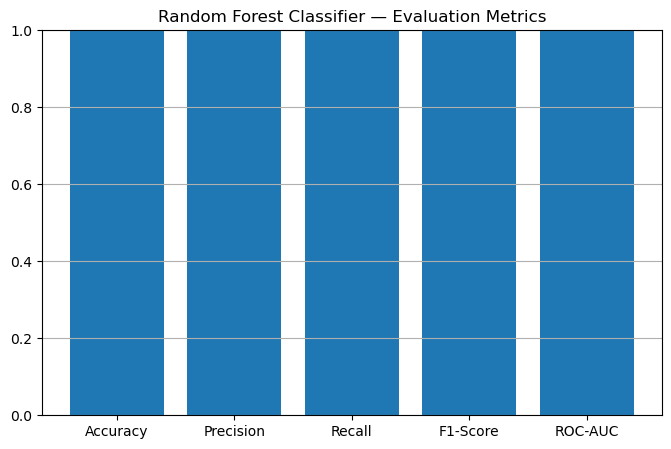

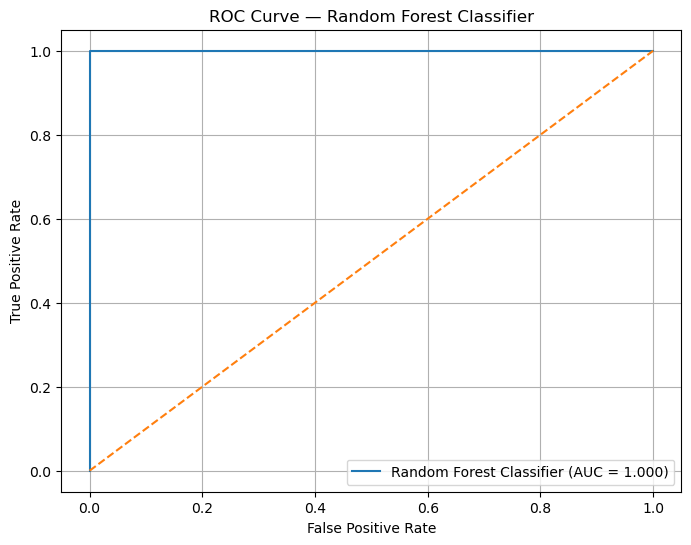

In [105]:
evaluate_and_plot(rf_clf, X_test, y_test, model_name="Random Forest Classifier")

The accuracy score and the Area Under ROC Curve (AUC) using Random Forest Classifier is 100%

The Random Forest Classifier achieved **perfect performance across all evaluation metrics**, with precision, recall, F1-score, and overall accuracy all equal to **1.00** for both classes. This indicates that the model classified both late and on-time deliveries without error on the test set. 

The ROC curve for the **Random Forest Classifier** shows an **AUC of 1.000**, indicating perfect classification performance on the test set. The curve remains at the top-left corner, showing that the model achieved an excellent true positive rate with virtually no false positives. This suggests very strong predictive ability. 

**XGBoost(Extreme Gradient Boosting) Classifier**

In [106]:
# XGBoost pipeline
xgb_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Days for shipping (real)',
                                                   'Days for shipment '
                                                   '(scheduled)',
                                                   'Benefit per order',
                                                   'Sales per customer',
                                                   'Category Id',
                                                   'Department Id', 'Latitude',
                                                   'Longitude',
                                                   'Order Item Discount',
                                                   'Order Item Discount Rate',
                                                   'Order Item Product Price',
                                                   'Order Item Profit Ratio',
          


=== XGBoost — Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16308
           1       1.00      1.00      1.00     19796

    accuracy                           1.00     36104
   macro avg       1.00      1.00      1.00     36104
weighted avg       1.00      1.00      1.00     36104



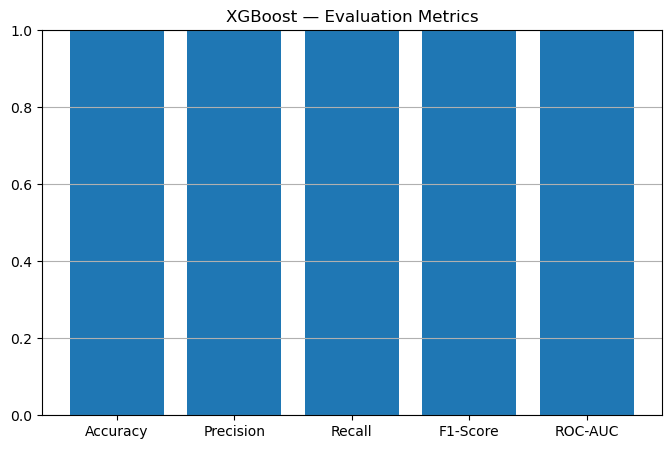

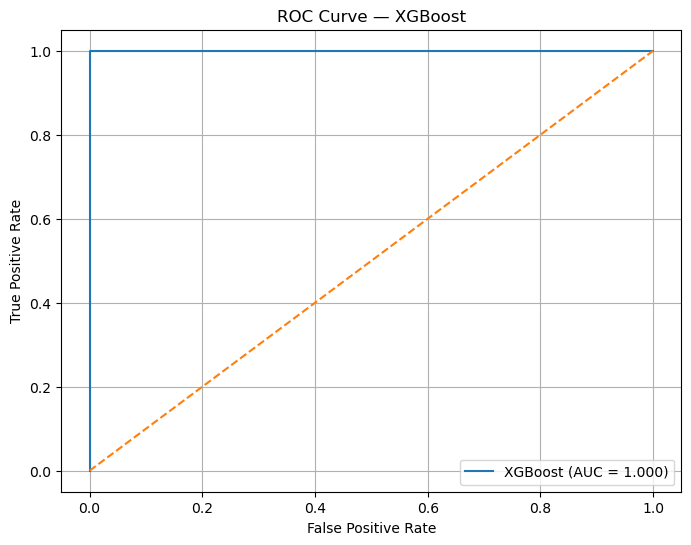

In [107]:
evaluate_and_plot(xgb_clf, X_test, y_test, model_name="XGBoost")

The **XGBoost** model achieved **perfect classification performance**, with precision, recall, F1-score, and overall accuracy all equal to **1.00** for both delivery classes. This indicates that the model correctly classified every on-time and late delivery instance in the test set. 

The ROC curve for **XGBoost** shows an **AUC of 1.000**, indicating perfect discrimination between late and on-time deliveries on the test set. The curve lies along the top-left boundary, showing that the model achieved an excellent true positive rate with almost no false positives. 

### Model Predictions

In [108]:
# Saving the model using .pkl
import joblib
joblib.dump(rf_clf, "Delivery Risk Fraud Prediction in Supply Chain Analytics.pki")

['Delivery Risk Fraud Prediction in Supply Chain Analytics.pki']

**Prediction On The Train Data**

In [109]:
modelname = RandomForestClassifier()

In [110]:
pred_train = rf_clf.predict(X_train)
print("Number of train predictions:", len(pred_train))

Number of train predictions: 144415


In [111]:
# prediction
prediction = rf_clf.predict(X_train)
prediction

array([1, 0, 1, ..., 1, 1, 0], dtype=int64)

Above are the predicted Supply Chain Risk on the train data.

In [112]:
a = np.array(y_train)
df_supply_chainRisk_train = pd.DataFrame()
df_supply_chainRisk_train["predicted"] = prediction
df_supply_chainRisk_train["original"] = a
df_supply_chainRisk_train

,predicted,original
0,1,1
1,0,0
2,1,1
3,0,0
4,1,1
...,...,...
144410,1,1
144411,1,1
144412,1,1
144413,1,1


**Prediction On The Test Data**

In [113]:
pred_test = rf_clf.predict(X_test)
print("Number of test predictions:", len(pred_test))

Number of test predictions: 36104


In [114]:
# prediction
prediction = rf_clf.predict(X_test)
prediction

array([0, 0, 0, ..., 0, 1, 1], dtype=int64)

Above are the predicted Supply Chain Risk on the test data.

In [115]:
a = np.array(y_test)
df_supply_chainRisk_test = pd.DataFrame()
df_supply_chainRisk_test["predicted"] = prediction
df_supply_chainRisk_test["original"] = a
df_supply_chainRisk_test

,predicted,original
0,0,0
1,0,0
2,0,0
3,0,0
4,1,1
...,...,...
36099,1,1
36100,0,0
36101,0,0
36102,1,1


### Summary and Conclusion

**Summary**

This project developed a **Machine learning model** to predict late delivery risk in supply chain operations using order, shipping, customer, and market data. Exploratory analysis showed that delayed deliveries were a major pattern in the dataset, while feature analysis revealed that shipping-related factors such as delay gap, actual shipping days, shipping mode risk, and tight schedules were the strongest drivers of late delivery risk. Two(2) models were tested, this are the Logistic Regression and the Random Forest and both models achieved perfect evaluation results on the test set.

**Conclusion**

The project shows that machine learning can effectively identify late delivery risk and support proactive logistics planning. The findings suggest that operational shipping factors are far more important than financial variables in explaining delays. Overall, the model demonstrates the value of **predictive analytics** in improving supply chain visibility, reducing delivery disruptions, and supporting better customer service outcomes.

### The End